## WaveNet Neural Network for EEG Data Classification


In [3]:
# Importing necessities 
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, Add, Activation, Multiply
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt # plotting
import numpy as np # linear algebra
import os # accessing directory structure
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import csv
import shutil
import pathlib 
import copy
import random
import itertools


import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np
import scipy.signal as signal
import scipy.stats as stats
import scipy.io as sio
import matplotlib.pyplot as plt


from random import sample as sm

import glob
import os
import mat73

import os
import h5py
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

import shutil
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

import os
import numpy as np
from scipy.io import loadmat

import tqdm
from tqdm import tqdm
import time

import os
import time
import numpy as np
import h5py
import tensorflow as tf
import json

import pickle
import tensorflow_addons as tfa

import os
import time
import h5py
import mat73
import scipy.io as sio
import random
import cupy as cp  # GPU-accelerated NumPy alternative
import numpy as np
from concurrent.futures import ProcessPoolExecutor

import os
import time
import json
import numpy as np
import h5py
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, metrics
from tensorflow.keras.callbacks import Callback, EarlyStopping
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns
import random
from tqdm.keras import TqdmCallback
import tensorflow_addons as tfa # Import tensorflow_addons for F1Score


## Process each file and save data to HDF5 #### GOOD VERSION 26/05/2025!!!


In [4]:
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm
import os
import random
import h5py
import numpy as np
import scipy.io as sio
import time

# (Assuming you have mat73 or remove that part if not needed)
import mat73  # If you don't use it, remove this import and related code


def process_file(file_info):
    file, label, base_dir = file_info
    data_path = os.path.join(base_dir, str(label), file)

    if not file.endswith('.mat'):
        return None

    data = None

    try:
        mat_file = mat73.loadmat(data_path)
        if 'data' in mat_file:
            data = mat_file['data'].T
    except:
        pass

    if data is None:
        try:
            with h5py.File(data_path, 'r') as hdf5:
                if 'data' in hdf5:
                    data = np.array(hdf5['data'])
        except:
            pass

    if data is None:
        try:
            mat_file = sio.loadmat(data_path)
            if 'data' in mat_file:
                data = mat_file['data'].flatten()
        except:
            pass

    if data is None:
        return None

    return file, label, data


def create_hdf5_parallel(dataset_dir, output_file, batch_size=10):
    if os.path.exists(output_file):
        os.remove(output_file)

    file_list = []
    for label in range(4):
        label_dir = os.path.join(dataset_dir, str(label))
        if not os.path.exists(label_dir):
            continue
        files = os.listdir(label_dir)
        random.shuffle(files)
        for file in files:
            file_list.append((file, label, dataset_dir))

    if not file_list:
        print("No files found to process.")
        return

    total_files = len(file_list)
    processed_count = 0

    with h5py.File(output_file, 'w') as hdf5_file, tqdm(total=total_files, desc="Processing Files") as pbar:
        for i in range(0, total_files, batch_size):
            batch_files = file_list[i:i + batch_size]

            with ThreadPoolExecutor() as executor:
                for result in executor.map(process_file, batch_files):
                    if result and isinstance(result, tuple):
                        filename, label, data = result
                        group = hdf5_file.require_group(f'label_{label}')
                        # Use a unique dataset name if duplicate filenames might exist
                        dset_name = f'file_{filename}'
                        if dset_name in group:
                            dset_name += f"_{processed_count}"
                        group.create_dataset(dset_name, data=data)

                    processed_count += 1
                    pbar.update(1)

    print(f"Successfully saved {processed_count} EEG files to {output_file}")


if __name__ == "__main__":
    start_time = time.time()

    
    dataset_dir = r'C:\DATA_EEG'
    
    ## Data test
    output_dir = r'C:\DATA_EEG\DataSetTest'
    dir_path = os.path.join(dataset_dir, 'DataSetTest')
    
    ## Data fnusa
    #output_dir = r'C:\DATA_EEG\DatasetFnusa'
    #dir_path = os.path.join(dataset_dir, 'DatasetFnusa\DatasetFnusa')
    ## DATA JOINED 
    #output_dir = r'C:\Users\caspe\OneDrive\Documenten\A_Casper\Brein\CS_Ai_Wolfhampton\Deep_machine_learning\CNN_EEG_project\DataSetTest'
    #dir_path = os.path.join(dataset_dir, 'DataSetTest')

    output_file = os.path.join(output_dir, 'dataset.h5')

    create_hdf5_parallel(dir_path, output_file, batch_size=10)   

Processing Files: 100%|██████████| 1003/1003 [00:34<00:00, 29.08it/s]

Successfully saved 1003 EEG files to C:\DATA_EEG\DataSetTest\dataset.h5


## Define model, train and plot

In [5]:
# ---------------------------
# Data Directories and Files
# ---------------------------
DATA_SAMPLE_PERCENTAGE = 1
epochs = 4
EARLY_STOPPING_PATIENCE = 3 

dataset_dir = r'C:\DATA_EEG'
output_dir = r'C:\DATA_EEG\Dataset_Joined'
dir_path = os.path.join(dataset_dir, 'DataSet_Joined')
main_dataset_file = os.path.join(output_dir, 'dataset.h5')

# Define paths for saving artifacts
MODEL_SAVE_PATH = os.path.join(output_dir, 'wavenet_model.keras') # Keras native format
HISTORY_SAVE_PATH = os.path.join(output_dir, 'training_history.json')
PLOTS_SAVE_DIR = os.path.join(output_dir, 'training_plots')
CLASS_WEIGHTS_SAVE_PATH = os.path.join(output_dir, 'class_weights.json')
OPTIMAL_THRESHOLD_SAVE_PATH = os.path.join(output_dir, 'optimal_f1_threshold.json')

NUM_CLASSES = 4
INPUT_SEQUENCE_LENGTH = 15000 # Adjusted to user's specified length
batch_size = 8 # Physical batch size
ACCUMULATION_STEPS = 4 # Number of physical batches to accumulate gradients over
INITIAL_LEARNING_RATE = 1e-3
L2_REGULARIZATION_LAMBDA = 1e-4

DILATED_CONV_FILTERS = 32
DILATED_CONV_KERNEL_SIZE = 2
# Reduced number of dilation rates to mitigate OOM and speed up training
DILATED_CONV_DILATION_RATES = [1, 2, 4, 8, 16, 32] # Reduced from [1, 2, 4, 8, 16, 32, 64]


train_ratio = 0.7
val_ratio = 0.2
test_ratio = 0.1

AUGMENTATION_PROBABILITY = 0.0 # Data augmentation is now disabled
NOISE_AMPLITUDE = 0.01
SCALE_FACTOR_MIN = 0.98
SCALE_FACTOR_MAX = 1.005



INITIAL_DROPOUT_RATE = 0.2
MIN_DROPOUT_RATE = 0.001
MAX_DROPOUT_RATE = 0.7
DROPOUT_SCALING_FACTOR = 0.05
DROPOUT_BASELINE_GAP = 0.02

CLASS_NAMES = ["Noise", "Artifacts", "Physiological", "Pathological"]
PLOT_HISTORY_METRICS = ['loss', 'accuracy', 'auc', 'precision', 'recall', 'f1_score_macro']
PLOT_EVERY_N_BATCHES = 50

USE_FOCAL_LOSS = True
FOCAL_LOSS_GAMMA = 2.0

OPTIMIZE_THRESHOLD_ON_VALIDATION = True
THRESHOLD_SEARCH_STEPS = 100

## keep above variables in this exact spot

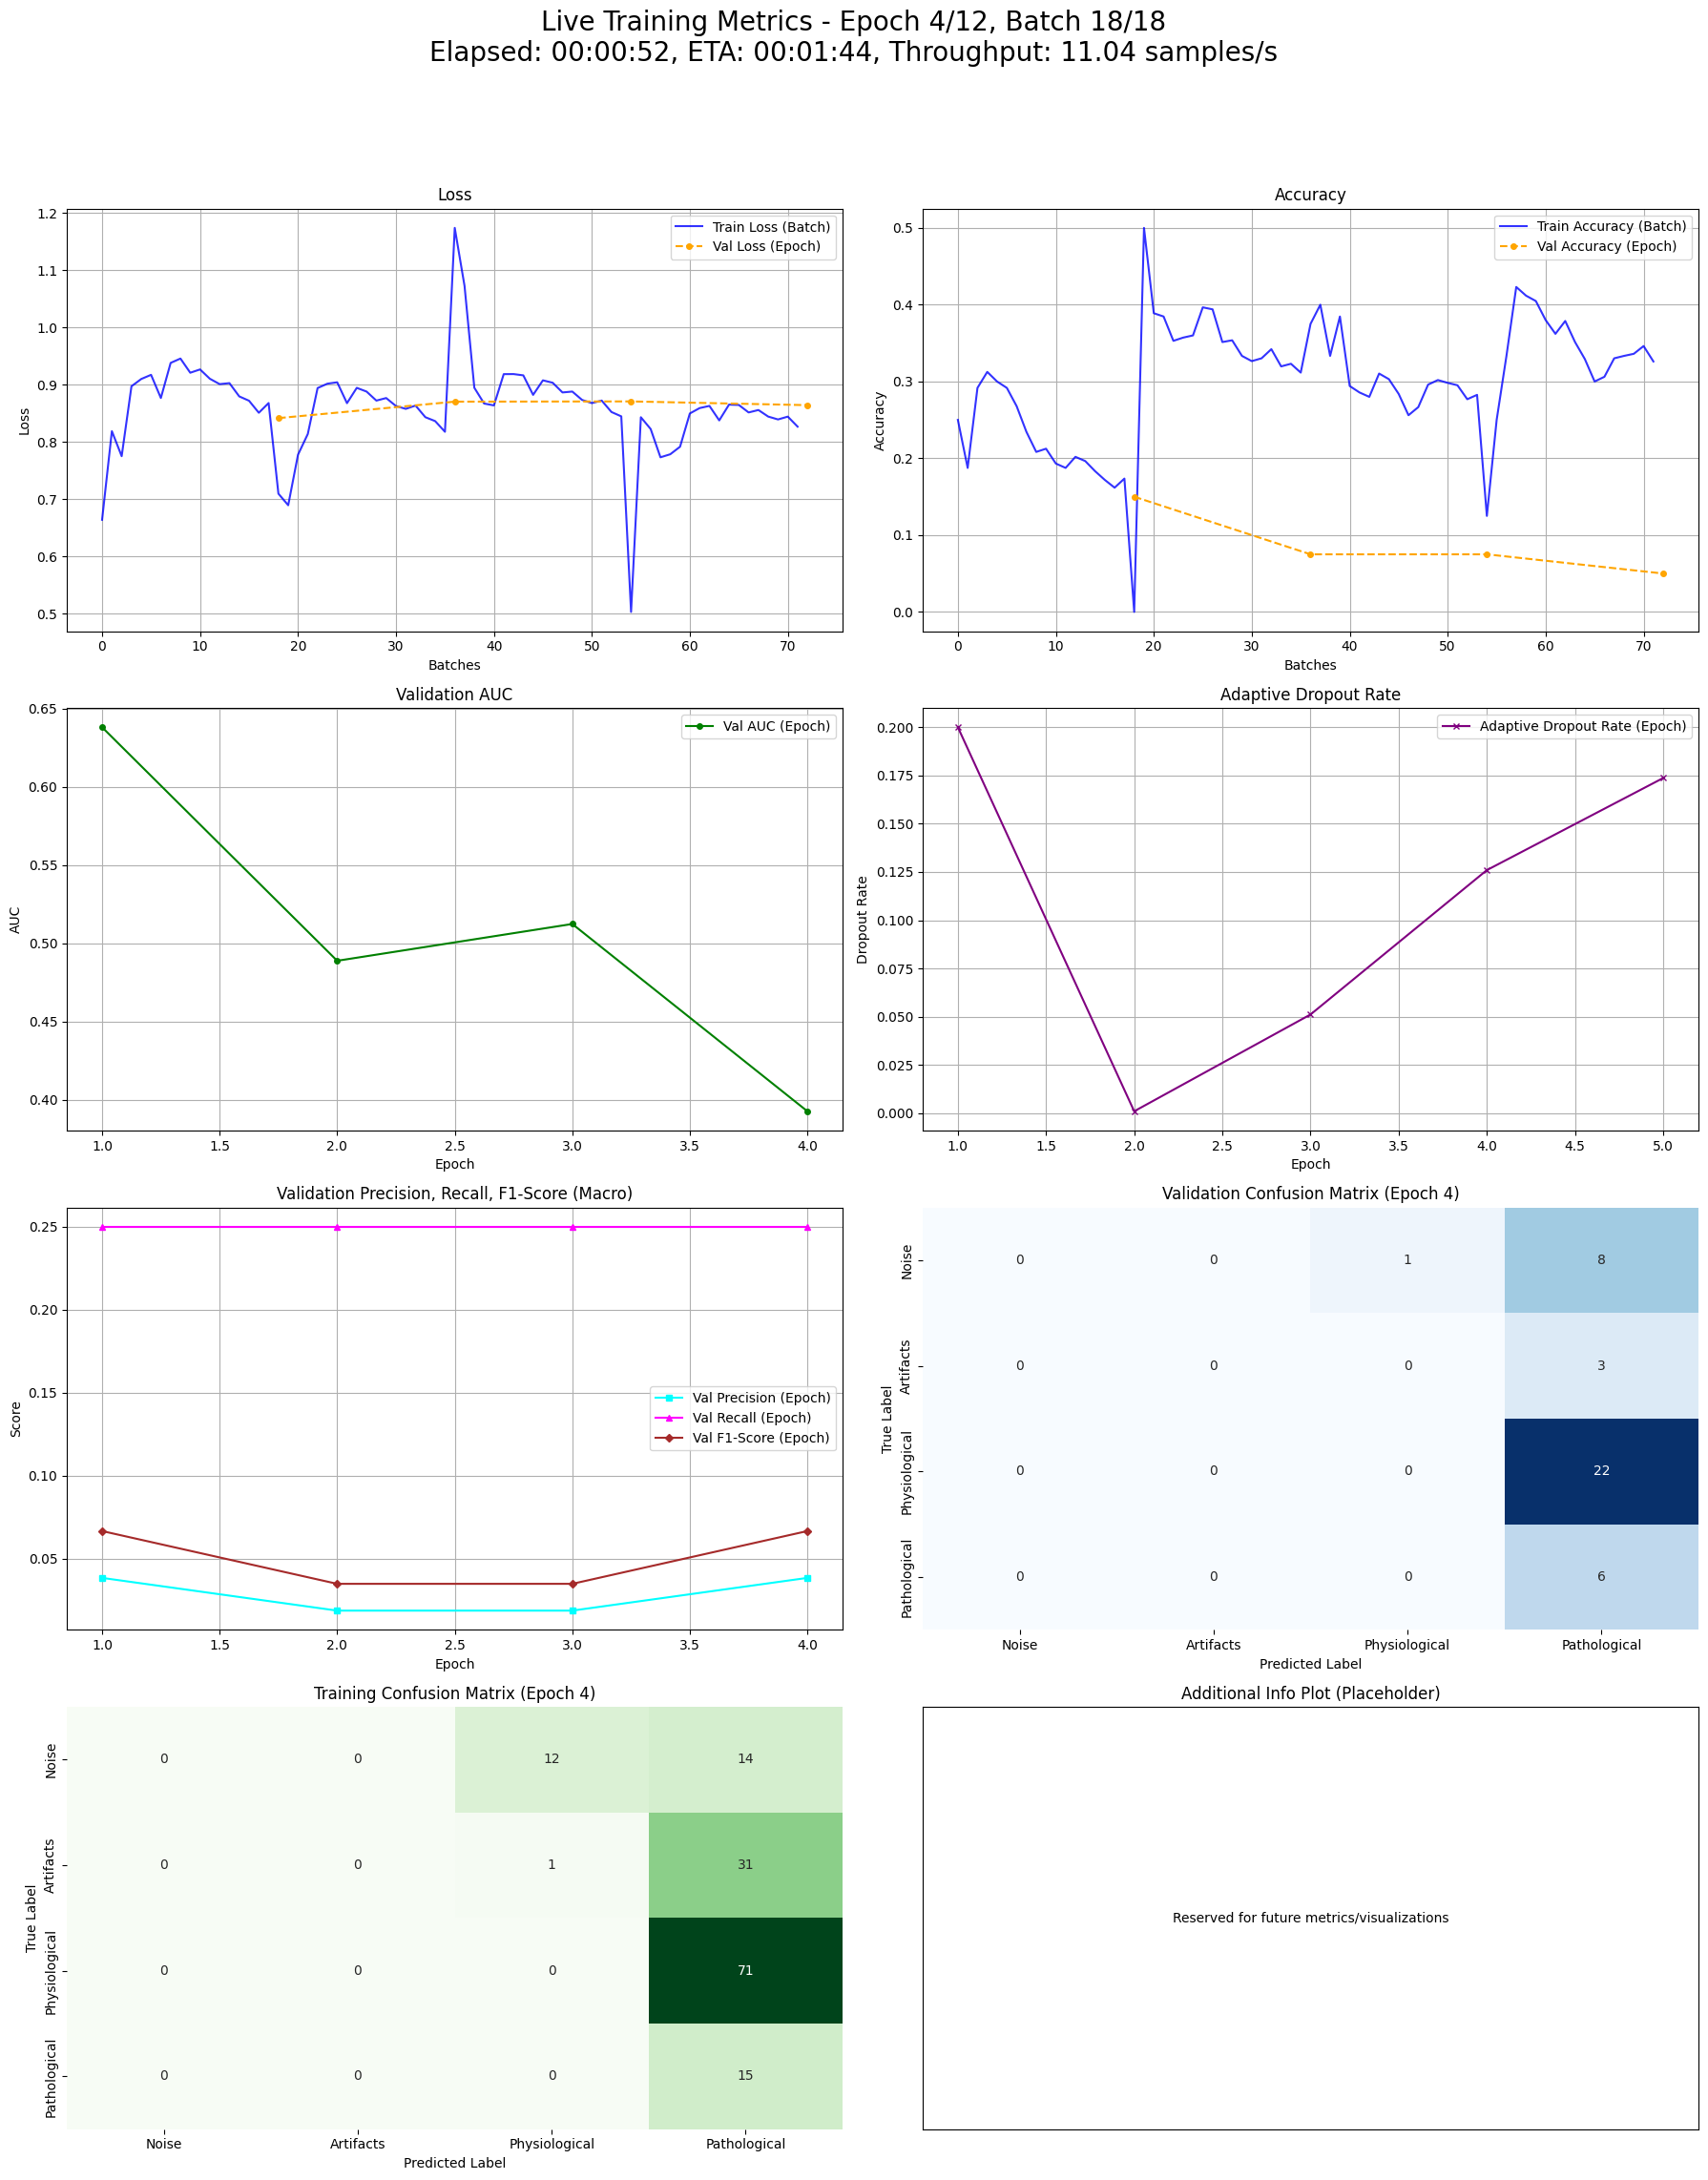

Epoch 4: early stopping

--- Model Training Complete ---

                     Training Summary                      

Total Training Duration: 00h 00m 53s
Epochs Trained: 4 (out of max 12)
Early Stopping Patience: 3 epochs (monitored 'val_loss')
Early Stopping triggered at epoch: 4

--- Model Architecture ---
Model: "WaveNet_Model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_sequence (InputLayer)    [(None, 15000, 1)]   0           []                               
                                                                                                  
 input_batchnorm (BatchNormaliz  (None, 15000, 1)    4           ['input_sequence[0][0]']         
 ation)                                                                                           
                                                                       

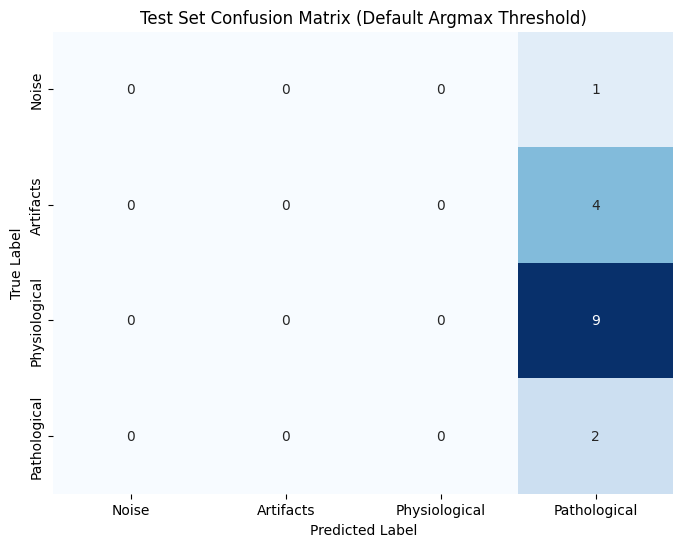

In [6]:
# ---------------------------
# Data Directories and Files
# ---------------------------
DATA_SAMPLE_PERCENTAGE = 0.001

dataset_dir = r'C:\DATA_EEG'
output_dir = r'C:\DATA_EEG\Dataset_Joined'
dir_path = os.path.join(dataset_dir, 'DataSet_Joined')
main_dataset_file = os.path.join(output_dir, 'dataset.h5')

# Define paths for saving artifacts
MODEL_SAVE_PATH = os.path.join(output_dir, 'wavenet_model.keras') # Keras native format
HISTORY_SAVE_PATH = os.path.join(output_dir, 'training_history.json')
PLOTS_SAVE_DIR = os.path.join(output_dir, 'training_plots')
CLASS_WEIGHTS_SAVE_PATH = os.path.join(output_dir, 'class_weights.json')
OPTIMAL_THRESHOLD_SAVE_PATH = os.path.join(output_dir, 'optimal_f1_threshold.json')

NUM_CLASSES = 4
INPUT_SEQUENCE_LENGTH = 15000 # Adjusted to user's specified length
epochs = 12
batch_size = 8 # Physical batch size
ACCUMULATION_STEPS = 4 # Number of physical batches to accumulate gradients over
INITIAL_LEARNING_RATE = 1e-3
L2_REGULARIZATION_LAMBDA = 1e-4

DILATED_CONV_FILTERS = 32
DILATED_CONV_KERNEL_SIZE = 2
# Reduced number of dilation rates to mitigate OOM and speed up training
DILATED_CONV_DILATION_RATES = [1, 2, 4, 8, 16] # Reduced from [1, 2, 4, 8, 16, 32, 64]


train_ratio = 0.7
val_ratio = 0.2
test_ratio = 0.1

AUGMENTATION_PROBABILITY = 0.0 # Data augmentation is now disabled
NOISE_AMPLITUDE = 0.01
SCALE_FACTOR_MIN = 0.98
SCALE_FACTOR_MAX = 1.005

EARLY_STOPPING_MONITOR = 'val_loss'
EARLY_STOPPING_PATIENCE = 3 # Reduced patience for faster training completion

INITIAL_DROPOUT_RATE = 0.2
MIN_DROPOUT_RATE = 0.001
MAX_DROPOUT_RATE = 0.7
DROPOUT_SCALING_FACTOR = 0.05
DROPOUT_BASELINE_GAP = 0.02

CLASS_NAMES = ["Noise", "Artifacts", "Physiological", "Pathological"]
PLOT_HISTORY_METRICS = ['loss', 'accuracy', 'auc', 'precision', 'recall', 'f1_score_macro']
PLOT_EVERY_N_BATCHES = 50

USE_FOCAL_LOSS = True
FOCAL_LOSS_GAMMA = 2.0

OPTIMIZE_THRESHOLD_ON_VALIDATION = True
THRESHOLD_SEARCH_STEPS = 100

## keep above variables in this exact spot

import os
import time
import json
import numpy as np
import h5py
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, metrics
from tensorflow.keras.callbacks import Callback, EarlyStopping
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns
import random
import tensorflow_addons as tfa
from IPython.display import clear_output

# Ensure the plots save directory exists
os.makedirs(PLOTS_SAVE_DIR, exist_ok=True)

# ---------------------------
# 1. Enable GPU Usage and Optimizations
# ---------------------------
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Using GPU: {gpus[0].name}")
    except RuntimeError as e:
        print(e)
else:
    print("No GPU found, using CPU.")

# Enable mixed precision
tf.keras.mixed_precision.set_global_policy('mixed_float16')
start_time = time.time() # This is the global start_time we need

# ---------------------------
# Swish Activation Function
# ---------------------------
def swish_activation(x):
    """
    Implements the Swish activation function: x * sigmoid(x).
    Swish is a smooth, non-monotonic activation function that tends to work
    better than ReLU on deeper models across a number of challenging datasets.
    """
    return x * tf.sigmoid(x)

# ---------------------------
# Custom Focal Loss Function
# ---------------------------
def focal_loss_fn(y_true, y_pred, gamma=2.0, alpha_weights=None):
    """
    Custom implementation of Focal Loss for multi-class classification.
    Args:
        y_true (tf.Tensor): True labels (one-hot encoded).
        y_pred (tf.Tensor): Predicted probabilities (after softmax).
        gamma (float): Focusing parameter. Higher gamma reduces the loss for
                       well-classified examples, focusing on hard examples.
        alpha_weights (tf.Tensor or None): Class-specific weighting factor.
                                           If None, all classes are weighted equally.
                                           Should be a tensor of shape (NUM_CLASSES,).
    Returns:
        tf.Tensor: Computed focal loss.
    """
    epsilon = tf.keras.backend.epsilon()
    y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon) # Clip to prevent log(0)
    # Calculate cross-entropy
    cross_entropy = -y_true * tf.math.log(y_pred)
    # Calculate p_t (probability of the true class)
    # y_true is one-hot, so y_true * y_pred gives 0 for incorrect classes and y_pred for true class
    p_t = tf.reduce_sum(y_true * y_pred, axis=-1, keepdims=True)
    # Calculate modulating factor (1 - p_t)^gamma
    modulating_factor = tf.pow(1.0 - p_t, gamma)
    # Apply alpha weights if provided
    if alpha_weights is not None:
        # Reshape alpha_weights to match y_true/y_pred for element-wise multiplication
        # alpha_weights should be (NUM_CLASSES,)
        # y_true/y_pred are (batch_size, NUM_CLASSES)
        alpha_factor = tf.reduce_sum(y_true * alpha_weights, axis=-1, keepdims=True)
        focal_loss = alpha_factor * modulating_factor * cross_entropy
    else:
        focal_loss = modulating_factor * cross_entropy
    return tf.reduce_sum(focal_loss, axis=-1) # Sum across classes for each sample

# ---------------------------
# HDF5 Generator (Modified for global shuffling)
# ---------------------------
def hdf5_generator(file_path, shuffled_keys_for_split):
    """
    A Python generator function to efficiently load and preprocess data
    from an HDF5 file based on a pre-shuffled list of keys.
    It yields normalized data tensors and one-hot encoded labels.
    Args:
        file_path (str): The path to the main HDF5 file (dataset.h5).
        shuffled_keys_for_split (list): A list of (label_str, file_name) tuples
                                        representing the samples for this specific split,
                                        already globally shuffled.
    Yields:
        tuple: A tuple containing:
            - tf.Tensor: The preprocessed data (normalized float32).
            - tf.Tensor: The integer label (int64).
    """
    # Open the HDF5 file once for the duration of the generator's existence
    with h5py.File(file_path, 'r') as hdf5_file:
        for label_str, file_name in shuffled_keys_for_split:
            dataset_key = f"{label_str}/{file_name}"
            if dataset_key not in hdf5_file:
                # print(f"Warning: Dataset key '{dataset_key}' not found in HDF5 file. Skipping.") # Uncomment for debugging
                continue
            try:
                # Load data, convert to float32, and normalize (Z-score)
                data = hdf5_file[dataset_key][:].astype(np.float32)
                data = (data - np.mean(data)) / (np.std(data) + 1e-8) # Add epsilon for stability
                int_label = int(label_str.split('_')[-1])
                # Yield data and label as TensorFlow tensors
                yield tf.convert_to_tensor(data.reshape((1, INPUT_SEQUENCE_LENGTH, 1)), dtype=tf.float32), \
                      tf.convert_to_tensor(np.array([int_label]), dtype=tf.int64)
            except Exception as e:
                print(f"HDF5 generator error for {dataset_key}: {e}. Skipping sample.")
                continue
    # The generator will exit when all keys in shuffled_keys_for_split have been processed.
    # The .repeat() on the dataset will then cause it to restart from the beginning of the shuffled keys.

# ---------------------------
# Preprocessing Functions
# ---------------------------
def reshape_input(x, y):
    """
    Reshapes the input tensor `x` by removing a singular dimension (axis=1).
    This is often needed when the generator yields data with an extra batch dimension.
    Args:
        x (tf.Tensor): The input data tensor.
        y (tf.Tensor): The label tensor.
    Returns:
        tuple: Reshaped x and original y.
    """
    return tf.squeeze(x, axis=1), y

def one_hot_encode_labels(x, y):
    """
    Converts integer labels `y` into one-hot encoded vectors.
    Args:
        x (tf.Tensor): The input data tensor.
        y (tf.Tensor): The integer label tensor.
    Returns:
        tuple: Original x and one-hot encoded y.
    """
    # Squeeze y to remove any singular dimensions before one-hot encoding
    y_one_hot = tf.one_hot(tf.squeeze(y, axis=-1), depth=NUM_CLASSES, dtype=tf.float32)
    return x, y_one_hot

# ---------------------------
# Data Augmentation Function (MODIFIED for 35% chance and wider range)
# ---------------------------
def apply_augmentation(x, y): # Removed probability parameter, now uses global AUGMENTATION_PROBABILITY
    """
    Adds random Gaussian noise and applies random amplitude scaling to the input
    time-series data with a given probability.
    Args:
        x (tf.Tensor): The input data tensor (time-series).
        y (tf.Tensor): The label tensor.
    Returns:
        tuple: Augmented x or original x, and original y.
    """
    def augment_true():
        # 1. Add Random Gaussian Noise
        noise = tf.random.normal(shape=tf.shape(x), mean=0.0, stddev=NOISE_AMPLITUDE, dtype=tf.float32)
        augmented_x = x + noise
        # 2. Random Amplitude Scaling
        scale_factor = tf.random.uniform(shape=[], minval=SCALE_FACTOR_MIN, maxval=SCALE_FACTOR_MAX, dtype=tf.float32)
        augmented_x = augmented_x * scale_factor
        return augmented_x

    def augment_false():
        return x # Return original x if augmentation is not applied

    # Generate a random uniform number
    rand_val = tf.random.uniform(shape=[], minval=0.0, maxval=1.0, dtype=tf.float32)
    # Conditionally apply augmentation based on the random number
    augmented_x = tf.cond(rand_val < AUGMENTATION_PROBABILITY, augment_true, augment_false)
    return augmented_x, y

# ---------------------------
# Dataset Creation (Modified)
# ---------------------------
def create_tf_dataset(file_path, batch_size, shuffled_keys_for_split, augment=False): # Added augment parameter
    """
    Creates a TensorFlow Dataset from the HDF5 generator, applying batching
    and preprocessing steps. Shuffling is handled by the pre-shuffled keys list.
    Args:
        file_path (str): The path to the main HDF5 file (dataset.h5).
        batch_size (int): The number of samples per batch.
        shuffled_keys_for_split (list): A list of (label_str, file_name) tuples
                                        representing the samples for this specific split,
                                        already globally shuffled.
        augment (bool): Whether to apply data augmentation. Set to True for training data.
    Returns:
        tf.data.Dataset: A configured TensorFlow Dataset ready for training/evaluation.
    """
    dataset = tf.data.Dataset.from_generator(
        lambda: hdf5_generator(file_path, shuffled_keys_for_split),
        output_signature=(
            tf.TensorSpec(shape=(1, INPUT_SEQUENCE_LENGTH, 1), dtype=tf.float32), # Data shape from generator
            tf.TensorSpec(shape=(1,), dtype=tf.int64) # Label shape from generator
        )
    )
    # Apply batching, repeat indefinitely for training, and map preprocessing functions
    # No need for .shuffle() here as keys are already shuffled globally
    dataset = dataset.batch(batch_size).repeat()
    if augment: # Apply augmentation ONLY if augment is True
        # Now apply_augmentation uses global AUGMENTATION_PROBABILITY
        dataset = dataset.map(apply_augmentation, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.map(reshape_input, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.map(one_hot_encode_labels, num_parallel_calls=tf.data.AUTOTUNE)
    return dataset.prefetch(tf.data.AUTOTUNE) # Prefetch for performance

# ---------------------------
# Adaptive Dropout & Metric Logging Callback (MODIFIED FOR COMPOSITE SCORE)
# ---------------------------
class MetricsAndAdaptiveDropout(Callback):
    """
    A custom Keras Callback that dynamically adjusts the dropout rate
    based on a composite score derived from multiple model performance metrics
    (validation accuracy, AUC, validation loss, and train/val accuracy gap).
    It also logs metrics to the console and passes dropout rate to a plotter.
    """
    def __init__(self, validation_data, verbose=0, initial_dropout=INITIAL_DROPOUT_RATE, min_dropout=MIN_DROPOUT_RATE, max_dropout=MAX_DROPOUT_RATE,
                     scaling_factor=DROPOUT_SCALING_FACTOR, baseline_gap=DROPOUT_BASELINE_GAP,
                     plotter_callback=None):
        super().__init__()
        self.validation_data_arg = validation_data
        self.verbose = verbose
        self.initial_dropout = initial_dropout
        self.min_dropout = min_dropout
        self.max_dropout = max_dropout
        self.scaling_factor = scaling_factor
        self.baseline_gap = baseline_gap # Used for the relative_gap component
        # Initialize previous values for metric comparison to calculate impact
        self.previous_val_acc = 0.0
        self.previous_auc = 0.0
        self.previous_val_loss = float('inf') # Start with a high loss
        self.current_dropout_rate = initial_dropout
        self.dropout_layer = None
        self.dropout_rate_history = []
        self.plotter_callback = plotter_callback

    def on_train_begin(self, logs=None):
        # Find the first dropout layer in the model to control its rate
        for layer in self.model.layers:
            # Check if the layer is a functional API layer or a sequential layer
            if hasattr(layer, 'layers'): # For functional API models, layers might be nested
                for sub_layer in layer.layers:
                    if isinstance(sub_layer, layers.Dropout):
                        self.dropout_layer = sub_layer
                        break
            if isinstance(layer, layers.Dropout): # For simple sequential models
                self.dropout_layer = layer
                break
        
        if self.dropout_layer is None:
            print("Warning: No Dropout layer found for AdaptiveDropout. Adaptive dropout will not function.")
        else:
            self.dropout_layer.rate = self.initial_dropout
            self.current_dropout_rate = self.initial_dropout
            if self.verbose > 0:
                print(f"Initial dropout rate set to: {self.initial_dropout:.4f}")
        self.dropout_rate_history.append(self.current_dropout_rate)
        if self.plotter_callback:
            self.plotter_callback.log_dropout_rate(self.current_dropout_rate)

    def on_epoch_end(self, epoch, logs=None):
        if self.dropout_layer is None:
            return
        logs = logs or {}
        train_acc = logs.get('accuracy', 0.0) # Training accuracy for relative gap
        val_acc = logs.get('val_accuracy', 0.0)
        auc = logs.get('val_auc', 0.0)
        val_loss = logs.get('val_loss', float('inf'))
        # Add a small epsilon to denominator to prevent division by zero
        relative_gap = (train_acc - val_acc) / max(train_acc, 1e-8) if train_acc > 0 else 0.0
        # Calculate the absolute difference first for clarity or reuse
        abs_val_acc_diff = abs(val_acc - self.previous_val_acc)
        # Now use it in the conditional assignment
        val_no_learn = abs_val_acc_diff if abs_val_acc_diff > 0.01 else 20
        # Calculate the impact of changes in metrics from the previous epoch
        # Positive impact value means metric is worsening (e.g., val_acc decreased, val_loss increased)
        # We want to increase dropout if performance worsens, so signs are chosen accordingly.
        val_acc_impact = (self.previous_val_acc - val_acc) * 1.5
        auc_impact = (self.previous_auc - auc) * 0.8
        val_loss_impact = (val_loss - self.previous_val_loss) * 1.0
        val_no_learn_impact = (val_no_learn)/25
        # Calculate the composite score
        composite_score = (
            val_acc_impact +
            auc_impact +
            val_loss_impact +
            (relative_gap - self.baseline_gap)+ # If relative gap is too high, this term increases score
            val_no_learn_impact
        )
        # Update dropout rate based on the composite score
        new_dropout = self.current_dropout_rate + (composite_score * self.scaling_factor)
        # Clip the new dropout rate within the defined min and max bounds
        new_dropout = min(max(new_dropout, self.min_dropout), self.max_dropout)
        # Update the dropout layer's rate
        self.dropout_layer.rate = new_dropout
        self.current_dropout_rate = new_dropout
        # Update previous metric values for the next epoch's calculation
        self.previous_val_acc = val_acc
        self.previous_auc = auc
        self.previous_val_loss = val_loss
        # Log the current dropout rate and update the plotter callback
        self.dropout_rate_history.append(self.current_dropout_rate)
        if self.plotter_callback:
            self.plotter_callback.log_dropout_rate(self.current_dropout_rate)
        if self.verbose > 0:
            print(f"\nEpoch {epoch+1}: Composite Score: {composite_score:.4f}, New Dropout Rate: {self.current_dropout_rate:.4f}")
            print(f"   (Val Acc: {val_acc:.4f}, AUC: {auc:.4f}, Val Loss: {val_loss:.4f}, Rel Gap: {relative_gap:.4f})")

    def get_config(self):
        config = super().get_config()
        config.update({
            'initial_dropout': float(self.initial_dropout),
            'min_dropout': float(self.min_dropout),
            'max_dropout': float(self.max_dropout),
            'scaling_factor': float(self.scaling_factor),
            'baseline_gap': float(self.baseline_gap),
        })
        return config

# ---------------------------
# Live Plotting Callback (Modified for batch-level plotting)
# ---------------------------
class BatchMetricsPlotter(Callback):
    """
    A Keras Callback for live plotting of training and validation metrics.
    Metrics are plotted per batch for training, and per epoch for validation.
    Includes Loss, Accuracy, AUC, Adaptive Dropout Rate, Precision, Recall, F1-Score, and Confusion Matrix.
    """
    def __init__(self, num_classes=NUM_CLASSES, val_dataset=None, validation_steps=None,
                     class_names=CLASS_NAMES, start_time=None, batch_size=None, steps_per_epoch=None, total_epochs=None,
                     plot_every_n_batches=PLOT_EVERY_N_BATCHES, train_dataset=None): # Added train_dataset
        super().__init__()
        self.batch_count = 0
        self.current_epoch = 0
        self.num_classes = num_classes
        self.val_dataset = val_dataset
        self.train_dataset = train_dataset # Store train_dataset
        self.validation_steps = validation_steps
        self.steps_per_epoch = steps_per_epoch # Also need steps_per_epoch for training CM
        self.class_names = class_names if class_names is not None else [str(i) for i in range(num_classes)]
        self.start_time = start_time if start_time is not None else time.time()
        self.batch_size = batch_size
        self.steps_per_epoch = steps_per_epoch
        self.total_epochs = total_epochs
        self.plot_every_n_batches = plot_every_n_batches # Store the interval
        self.train_loss_history = []
        self.train_accuracy_history = []
        self.val_loss_history = []
        self.val_accuracy_history = []
        self.val_auc_history = []
        self.dropout_rate_history = [] # To be populated by AdaptiveDropout callback
        self.val_precision_history = []
        self.val_recall_history = []
        self.val_f1_score_history = []
        self.confusion_matrix_history = []
        self.train_confusion_matrix_history = [] # New: for training confusion matrix
        plt.ion() # Enable interactive plotting

    def on_epoch_begin(self, epoch, logs=None):
        self.current_epoch = epoch + 1
        # NOT clearing train_confusion_matrix_history here as requested
        # self.train_confusion_matrix_history = [] # REMOVED THIS LINE
        # This means the last epoch's training CM will persist until the new epoch completes.

    def on_train_batch_end(self, batch, logs=None):
        logs = logs or {}
        self.batch_count += 1
        self.train_loss_history.append(logs.get('loss', 0))
        self.train_accuracy_history.append(logs.get('accuracy', 0))
        # Plot only if it's time to plot
        if self.batch_count % self.plot_every_n_batches == 0:
            self._update_plot(is_batch_plot=True) # Pass flag to indicate batch plot

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        self.val_loss_history.append(logs.get('val_loss', 0))
        self.val_accuracy_history.append(logs.get('val_accuracy', 0))
        self.val_auc_history.append(logs.get('val_auc', 0))
        self.current_epoch = epoch + 1
        val_true_labels_epoch = []
        val_predicted_probs_epoch = []
        if self.model and self.val_dataset and self.validation_steps:
            val_data_iterator = iter(self.val_dataset)
            for _ in range(self.validation_steps):
                try:
                    val_x_batch, val_y_true_batch = next(val_data_iterator)
                    val_predicted_probs_batch = self.model.predict(val_x_batch, verbose=0)
                    val_true_labels_epoch.extend(tf.argmax(val_y_true_batch, axis=-1).numpy())
                    val_predicted_probs_epoch.extend(val_predicted_probs_batch)
                except tf.errors.OutOfRangeError:
                    print("Warning: Validation dataset exhausted prematurely during epoch end prediction.")
                    break
        if val_true_labels_epoch and val_predicted_probs_epoch:
            y_true_np = np.array(val_true_labels_epoch)
            y_pred_probs_np = np.array(val_predicted_probs_epoch)
            y_pred_classes_np = np.argmax(y_pred_probs_np, axis=-1)
            cm = confusion_matrix(y_true_np, y_pred_classes_np, labels=np.arange(self.num_classes))
            self.confusion_matrix_history.append(cm)
            macro_precision = precision_score(y_true_np, y_pred_classes_np, average='macro', zero_division=0)
            macro_recall = recall_score(y_true_np, y_pred_classes_np, average='macro', zero_division=0)
            macro_f1 = f1_score(y_true_np, y_pred_classes_np, average='macro', zero_division=0)
            self.val_precision_history.append(macro_precision)
            self.val_recall_history.append(macro_recall)
            self.val_f1_score_history.append(macro_f1)
        else:
            self.confusion_matrix_history.append(np.zeros((self.num_classes, self.num_classes), dtype=int))
            self.val_precision_history.append(0.0)
            self.val_recall_history.append(0.0)
            self.val_f1_score_history.append(0.0)
        # New: Collect data and generate confusion matrix for training dataset at epoch end
        train_true_labels_epoch = []
        train_predicted_probs_epoch = []
        if self.model and self.train_dataset and self.steps_per_epoch:
            # Create a temporary iterator for one full pass over the training data for CM
            train_data_iterator_cm = iter(self.train_dataset.unbatch().batch(self.batch_size).take(self.steps_per_epoch))
            for _ in range(self.steps_per_epoch):
                try:
                    train_x_batch, train_y_true_batch = next(train_data_iterator_cm)
                    train_predicted_probs_batch = self.model.predict(train_x_batch, verbose=0)
                    train_true_labels_epoch.extend(tf.argmax(train_y_true_batch, axis=-1).numpy())
                    train_predicted_probs_epoch.extend(train_predicted_probs_batch)
                except tf.errors.OutOfRangeError:
                    print("Warning: Training dataset exhausted prematurely during epoch end training CM prediction.")
                    break
        if train_true_labels_epoch and train_predicted_probs_epoch:
            train_y_true_np = np.array(train_true_labels_epoch)
            train_y_pred_probs_np = np.array(train_predicted_probs_epoch)
            train_y_pred_classes_np = np.argmax(train_y_pred_probs_np, axis=-1)
            train_cm = confusion_matrix(train_y_true_np, train_y_pred_classes_np, labels=np.arange(self.num_classes))
            self.train_confusion_matrix_history.append(train_cm)
        else:
            self.train_confusion_matrix_history.append(np.zeros((self.num_classes, self.num_classes), dtype=int))
        # Trigger a final plot update at the end of the epoch to show latest validation metrics
        self._update_plot(is_batch_plot=False) # Pass flag to indicate epoch plot

    def log_dropout_rate(self, dropout_rate):
        self.dropout_rate_history.append(dropout_rate)

    def _update_plot(self, is_batch_plot=True, final_save=False):
        """
        Clears the output and redraws the plot with 8 subplots (4x2 layout),
        showing batch-level training metrics, epoch-level validation metrics,
        adaptive dropout rate, and confusion matrix, along with a progress bar.
        If final_save is True, saves the plot to a file.
        """
        if not final_save:
            clear_output(wait=True) # Clear previous plot output
        
        fig, axes = plt.subplots(4, 2, figsize=(18, 24)) # Increased height for 4 rows
        axes = axes.flatten() # Flatten for easier indexing

        # Calculate dynamic stats for the title
        elapsed_seconds = time.time() - self.start_time
        total_samples_processed = self.batch_count * self.batch_size if self.batch_size is not None else 0
        samples_per_second = total_samples_processed / elapsed_seconds if elapsed_seconds > 0 else 0
        
        # Format elapsed time
        el_h = int(elapsed_seconds // 3600)
        el_m = int((elapsed_seconds % 3600) // 60)
        el_s = int(elapsed_seconds % 60)
        elapsed_formatted = f'{el_h:02d}:{el_m:02d}:{el_s:02d}'
        
        # Calculate estimated remaining time (ETA)
        eta_str = ""
        if self.steps_per_epoch and self.total_epochs and self.batch_size and samples_per_second > 0:
            total_batches = self.steps_per_epoch * self.total_epochs
            batches_remaining = total_batches - self.batch_count
            if batches_remaining > 0:
                estimated_remaining_seconds = batches_remaining * self.batch_size / samples_per_second
                rem_h = int(estimated_remaining_seconds // 3600)
                rem_m = int((estimated_remaining_seconds % 3600) // 60)
                rem_s = int(estimated_remaining_seconds % 60)
                eta_str = f', ETA: {rem_h:02d}:{rem_m:02d}:{rem_s:02d}'
            else:
                eta_str = ', ETA: 00:00:00'
        
        current_batch_in_epoch = (self.batch_count - 1) % self.steps_per_epoch + 1
        fig.suptitle(f'Live Training Metrics - Epoch {self.current_epoch}/{self.total_epochs}, Batch {current_batch_in_epoch}/{self.steps_per_epoch}\n'
                             f'Elapsed: {elapsed_formatted}{eta_str}, Throughput: {samples_per_second:.2f} samples/s',
                             fontsize=20)
        
        # Plot 1: Loss
        axes[0].plot(self.train_loss_history, label='Train Loss (Batch)', color='blue', alpha=0.8)
        if self.val_loss_history:
            val_x = np.arange(1, len(self.val_loss_history) + 1) * self.steps_per_epoch
            axes[0].plot(val_x, self.val_loss_history, label='Val Loss (Epoch)', color='orange', linestyle='--', marker='o', markersize=4)
        axes[0].set_title('Loss')
        axes[0].set_xlabel('Batches')
        axes[0].set_ylabel('Loss')
        axes[0].legend()
        axes[0].grid(True)
        
        # Plot 2: Accuracy
        axes[1].plot(self.train_accuracy_history, label='Train Accuracy (Batch)', color='blue', alpha=0.8)
        if self.val_accuracy_history:
            val_x = np.arange(1, len(self.val_accuracy_history) + 1) * self.steps_per_epoch
            axes[1].plot(val_x, self.val_accuracy_history, label='Val Accuracy (Epoch)', color='orange', linestyle='--', marker='o', markersize=4)
        axes[1].set_title('Accuracy')
        axes[1].set_xlabel('Batches')
        axes[1].set_ylabel('Accuracy')
        axes[1].legend()
        axes[1].grid(True)
        
        # Plot 3: Validation AUC (Epoch-level)
        if self.val_auc_history:
            axes[2].plot(np.arange(len(self.val_auc_history)) + 1, self.val_auc_history, label='Val AUC (Epoch)', color='green', marker='o', markersize=4)
            axes[2].set_title('Validation AUC')
            axes[2].set_xlabel('Epoch')
            axes[2].set_ylabel('AUC')
            axes[2].legend()
            axes[2].grid(True)
        else:
            axes[2].set_title('Validation AUC (Epoch-End Only)')
            axes[2].text(0.5, 0.5, 'Data available after epoch 1',
                                 horizontalalignment='center', verticalalignment='center', transform=axes[2].transAxes)
        
        # Plot 4: Adaptive Dropout Rate (Epoch-level)
        if self.dropout_rate_history:
            axes[3].plot(np.arange(len(self.dropout_rate_history)) + 1, self.dropout_rate_history, label='Adaptive Dropout Rate (Epoch)', color='purple', marker='x', markersize=4)
            axes[3].set_title('Adaptive Dropout Rate')
            axes[3].set_xlabel('Epoch')
            axes[3].set_ylabel('Dropout Rate')
            axes[3].legend()
            axes[3].grid(True)
        else:
            axes[3].set_title('Adaptive Dropout Rate (Epoch-End Only)')
            axes[3].text(0.5, 0.5, 'Data available after epoch 1',
                                 horizontalalignment='center', verticalalignment='center', transform=axes[3].transAxes)
        
        # Plot 5: Precision, Recall, F1-Score (Epoch-level)
        if self.val_precision_history:
            axes[4].plot(np.arange(len(self.val_precision_history)) + 1, self.val_precision_history, label='Val Precision (Epoch)', color='cyan', marker='s', markersize=4)
            axes[4].plot(np.arange(len(self.val_recall_history)) + 1, self.val_recall_history, label='Val Recall (Epoch)', color='magenta', marker='^', markersize=4)
            axes[4].plot(np.arange(len(self.val_f1_score_history)) + 1, self.val_f1_score_history, label='Val F1-Score (Epoch)', color='brown', marker='D', markersize=4)
            axes[4].set_title('Validation Precision, Recall, F1-Score (Macro)')
            axes[4].set_xlabel('Epoch')
            axes[4].set_ylabel('Score')
            axes[4].legend()
            axes[4].grid(True)
        else:
            axes[4].set_title('Validation PRF1 (Epoch-End Only)')
            axes[4].text(0.5, 0.5, 'Data available after epoch 1',
                                 horizontalalignment='center', verticalalignment='center', transform=axes[4].transAxes)
        
        # Plot 6: Validation Confusion Matrix (Latest Epoch)
        if self.confusion_matrix_history:
            latest_cm = self.confusion_matrix_history[-1]
            sns.heatmap(latest_cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[5],
                        xticklabels=self.class_names, yticklabels=self.class_names)
            axes[5].set_title(f'Validation Confusion Matrix (Epoch {self.current_epoch})')
            axes[5].set_xlabel('Predicted Label')
            axes[5].set_ylabel('True Label')
        else:
            axes[5].set_title('Validation Confusion Matrix (Epoch-End Only)')
            axes[5].text(0.5, 0.5, 'Data available after epoch 1',
                                 horizontalalignment='center', verticalalignment='center', transform=axes[5].transAxes)
        
        # Plot 7: Training Confusion Matrix (Latest Epoch)
        if self.train_confusion_matrix_history:
            latest_train_cm = self.train_confusion_matrix_history[-1]
            sns.heatmap(latest_train_cm, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[6],
                        xticklabels=self.class_names, yticklabels=self.class_names)
            axes[6].set_title(f'Training Confusion Matrix (Epoch {self.current_epoch})')
            axes[6].set_xlabel('Predicted Label')
            axes[6].set_ylabel('True Label')
        else:
            axes[6].set_title('Training Confusion Matrix (Epoch-End Only)')
            axes[6].text(0.5, 0.5, 'Data available after epoch 1',
                                 horizontalalignment='center', verticalalignment='center', transform=axes[6].transAxes)
        
        # Plot 8: Placeholder for additional info
        axes[7].set_title('Additional Info Plot (Placeholder)')
        axes[7].text(0.5, 0.5, 'Reserved for future metrics/visualizations',
                             horizontalalignment='center', verticalalignment='center', transform=axes[7].transAxes)
        axes[7].set_xticks([])
        axes[7].set_yticks([])
        axes[7].grid(False)
        
        plt.tight_layout(rect=[0, 0.03, 1, 0.94]) # Adjust layout to prevent title overlap
        
        if final_save:
            try:
                # Save the main plot
                plt.savefig(os.path.join(PLOTS_SAVE_DIR, 'final_training_metrics.png'))
                print(f"Final training metrics plot saved to: {os.path.join(PLOTS_SAVE_DIR, 'final_training_metrics.png')}")
                
                # Save individual confusion matrices
                if self.confusion_matrix_history:
                    plt.figure(figsize=(8, 6))
                    sns.heatmap(self.confusion_matrix_history[-1], annot=True, fmt='d', cmap='Blues', cbar=False,
                                xticklabels=self.class_names, yticklabels=self.class_names)
                    plt.title('Final Validation Confusion Matrix')
                    plt.xlabel('Predicted Label')
                    plt.ylabel('True Label')
                    plt.savefig(os.path.join(PLOTS_SAVE_DIR, 'final_val_confusion_matrix.png'))
                    plt.close() # Close figure to free memory
                    print(f"Final validation confusion matrix saved to: {os.path.join(PLOTS_SAVE_DIR, 'final_val_confusion_matrix.png')}")

                if self.train_confusion_matrix_history:
                    plt.figure(figsize=(8, 6))
                    sns.heatmap(self.train_confusion_matrix_history[-1], annot=True, fmt='d', cmap='Greens', cbar=False,
                                xticklabels=self.class_names, yticklabels=self.class_names)
                    plt.title('Final Training Confusion Matrix')
                    plt.xlabel('Predicted Label')
                    plt.ylabel('True Label')
                    plt.savefig(os.path.join(PLOTS_SAVE_DIR, 'final_train_confusion_matrix.png'))
                    plt.close() # Close figure to free memory
                    print(f"Final training confusion matrix saved to: {os.path.join(PLOTS_SAVE_DIR, 'final_train_confusion_matrix.png')}")

            except Exception as e:
                print(f"Error saving plots: {e}")
        else:
            plt.show()


# Helper Function to Get All Sample Keys (for global shuffling)
def _get_all_sample_keys(file_path, sample_percentage=1.0):
    """
    Reads all (label_str, file_name) tuples from an HDF5 file,
    then randomly samples a specified percentage of these keys.
    This reads only the keys/metadata, not the full data, to minimize memory usage.
    Args:
        file_path (str): The path to the main HDF5 file.
        sample_percentage (float): The percentage of total samples to use (e.g., 0.1 for 10%).
                                   Must be between 0.0 and 1.0.
    Returns:
        list: A randomly sampled and shuffled list of (label_str, file_name) tuples.
    """
    all_keys = []
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Main dataset file not found: {file_path}")
    with h5py.File(file_path, 'r') as hdf5_file:
        for label_str in hdf5_file.keys(): # Iterate directly over top-level groups (labels)
            for file_name in hdf5_file[label_str].keys(): # Iterate over datasets (files) within each label group
                all_keys.append((label_str, file_name))
    num_total_samples = len(all_keys)
    num_samples_to_keep = int(num_total_samples * sample_percentage)
    if num_samples_to_keep == 0 and num_total_samples > 0:
        print(f"Warning: sample_percentage {sample_percentage*100}% results in 0 samples. Keeping at least 1 if available.")
        num_samples_to_keep = 1 if num_total_samples > 0 else 0
    elif num_samples_to_keep > num_total_samples:
        print(f"Warning: sample_percentage {sample_percentage*100}% is greater than 100%. Using all {num_total_samples} samples.")
        num_samples_to_keep = num_total_samples
    if num_samples_to_keep > 0:
        sampled_keys = random.sample(all_keys, num_samples_to_keep)
    else:
        sampled_keys = []
    random.shuffle(sampled_keys)
    return sampled_keys

# Function to get class distribution from a list of (label_str, filename) keys
def get_class_distribution_from_keys(keys_list, num_classes):
    counts = np.zeros(num_classes, dtype=int)
    for label_str, _ in keys_list:
        try:
            int_label = int(label_str.split('_')[-1])
            if 0 <= int_label < num_classes:
                counts[int_label] += 1
        except ValueError:
            print(f"Warning: Could not parse label string '{label_str}' to an integer. Skipping.")
    return counts

# Function to find optimal F1-score threshold for multi-class classification
def find_optimal_f1_threshold(dataset_with_preds_and_labels, num_classes, threshold_steps=100):
    """
    Finds the optimal probability threshold that maximizes the macro F1-score
    for multi-class classification. This threshold is applied to the highest
    predicted probability for each sample. Samples with max_prob below the threshold
    are effectively treated as "unclassified" for F1 calculation.
    Args:
        dataset_with_preds_and_labels (tf.data.Dataset): A dataset yielding (predicted_probabilities, true_labels).
        num_classes (int): The number of output classes.
        threshold_steps (int): Number of thresholds to check between 0.01 and 0.99.
    Returns:
        tuple: (optimal_threshold, best_f1_score)
    """
    all_true_labels = []
    all_predicted_probs = []
    # Get true labels and predicted probabilities from the dataset
    # Add .batch(batch_size) to ensure iteration yields batches, not single elements
    for y_pred_probs_batch, y_true_batch in dataset_with_preds_and_labels.batch(batch_size):
        all_true_labels.extend(y_true_batch.numpy())
        all_predicted_probs.extend(y_pred_probs_batch.numpy())

    if not all_true_labels:
        print("Warning: No data found in the dataset for optimal threshold search.")
        return 0.0, 0.0

    y_true_np = np.array(all_true_labels)
    y_pred_probs_np = np.array(all_predicted_probs)
    thresholds = np.linspace(0.01, 0.99, threshold_steps) # Avoid 0 and 1 for practical reasons
    best_f1 = -1
    optimal_threshold = 0.0
    print(f"\nSearching for optimal F1-score threshold on {len(all_true_labels)} samples...")

    for t in thresholds:
        # Get the predicted class for each sample (argmax)
        predicted_classes_at_t = np.argmax(y_pred_probs_np, axis=-1)
        # Get the maximum probability for each sample
        max_probs = np.max(y_pred_probs_np, axis=-1)
        # Create a mask for confident predictions (max_prob >= threshold)
        confident_mask = max_probs >= t
        # Filter true labels and predictions based on confidence
        y_true_filtered = y_true_np[confident_mask]
        y_pred_filtered = predicted_classes_at_t[confident_mask]

        if len(y_true_filtered) > 0:
            # Calculate macro F1-score only for confident predictions
            current_f1 = f1_score(y_true_filtered, y_pred_filtered, average='macro', zero_division=0)
            if current_f1 > best_f1:
                best_f1 = current_f1
                optimal_threshold = t
        # else: if no confident predictions, F1 remains -1 (or 0)

    print(f"Optimal Threshold Found: {optimal_threshold:.4f} with Macro F1-score: {best_f1:.4f}")
    return optimal_threshold, best_f1


# ---------------------------
# Define WaveNet Model with Residual and Skip Connections (Functional API)
# ---------------------------
def create_wavenet_model(input_shape, num_classes, initial_dropout_rate, l2_lambda,
                         dilated_conv_filters, dilated_conv_kernel_size, dilated_conv_dilation_rates):
    """
    Creates a WaveNet model with residual and skip connections using the Keras Functional API.
    """
    l2_regularizer = tf.keras.regularizers.l2(l2_lambda)

    input_layer = layers.Input(shape=input_shape, name='input_sequence')
    
    # Initial Batch Normalization
    x = layers.BatchNormalization(name='input_batchnorm')(input_layer)

    # Initial 1x1 convolution to expand feature dimension if input features don't match DILATED_CONV_FILTERS
    # This prepares the input for the residual blocks
    if input_shape[-1] != dilated_conv_filters:
        x = layers.Conv1D(filters=dilated_conv_filters, kernel_size=1, padding='causal',
                          kernel_regularizer=l2_regularizer, name='initial_projection')(x)

    current_layer = x
    skip_connections = []
    dilated_conv_layers_info = [] # To store info for printing hyperparameters

    # Build sequential dilated convolutional blocks
    for i, dilation_rate in enumerate(dilated_conv_dilation_rates):
        # Store the input to this specific residual block
        residual_input = current_layer

        # Gated activation (simplified: using Swish for both branches)
        # In a full WaveNet, this would typically involve two parallel Conv1D layers
        # with tanh and sigmoid activations, then multiplied.
        # For simplicity and consistency with previous code, we'll use a single Swish.
        
        # Main dilated causal convolution
        x_conv = layers.Conv1D(filters=dilated_conv_filters,
                               kernel_size=dilated_conv_kernel_size,
                               dilation_rate=dilation_rate,
                               padding='causal',
                               kernel_regularizer=l2_regularizer,
                               name=f'dilated_conv1d_main_{i+1}_rate{dilation_rate}')(current_layer)
        
        # Apply Swish activation
        x_activated = swish_activation(x_conv)

        # Skip connection: Output from the activated conv goes to a 1x1 conv
        s = layers.Conv1D(filters=dilated_conv_filters, # Filters can be different from main path if needed
                          kernel_size=1,
                          padding='causal',
                          kernel_regularizer=l2_regularizer,
                          name=f'skip_conv1d_{i+1}_rate{dilation_rate}')(x_activated)
        skip_connections.append(s)

        # Residual connection: Transform the output of the main dilated conv
        # and add it back to the *input* of this block.
        # The filters MUST match the dimension of `residual_input`.
        res_output = layers.Conv1D(filters=dilated_conv_filters,
                                   kernel_size=1,
                                   padding='causal',
                                   kernel_regularizer=l2_regularizer,
                                   name=f'residual_conv1d_{i+1}_rate{dilation_rate}')(x_activated)

        # Add the residual output to the block's input. This becomes the input for the *next* block.
        current_layer = layers.Add(name=f'residual_add_{i+1}_rate{dilation_rate}')([residual_input, res_output])

        # Apply dropout after each residual block
        if initial_dropout_rate > 0:
            current_layer = layers.Dropout(initial_dropout_rate, name=f'dropout_{i+1}_rate{dilation_rate}')(current_layer)
        
        # Store info for printing hyperparameters
        dilated_conv_layers_info.append({
            'layer_name': f'dilated_conv1d_main_{i+1}_rate{dilation_rate}',
            'filters': dilated_conv_filters,
            'kernel_size': dilated_conv_kernel_size,
            'padding': 'causal',
            'activation': 'swish_activation', # Note: actual activation is applied after Conv1D
            'dilation_rate': dilation_rate,
            'l2_regularization': l2_lambda,
            'initial_dropout_rate': initial_dropout_rate
        })

    # Sum all skip connections from all blocks
    if len(skip_connections) > 1:
        summed_skips = layers.Add(name='summed_skip_connections')(skip_connections)
    else:
        summed_skips = skip_connections[0] # If only one dilation rate, just use that skip

    # Final output layers applied to the sum of skip connections
    # Two 1x1 convolutions after summing skips, as is common in WaveNet
    x = layers.Conv1D(filters=dilated_conv_filters, kernel_size=1, activation='relu',
                      kernel_regularizer=l2_regularizer, name='post_skip_conv1')(summed_skips)
    x = layers.Conv1D(filters=num_classes, kernel_size=1,
                      kernel_regularizer=l2_regularizer, name='post_skip_conv2')(x)

    x = layers.GlobalAveragePooling1D(name='global_average_pooling')(x)
    output_layer = layers.Activation('softmax', dtype='float32', name='softmax_output')(x)

    model = tf.keras.Model(inputs=input_layer, outputs=output_layer, name='WaveNet_Model')
    return model, dilated_conv_layers_info

# --- Main Script Execution ---
# Get a sampled subset of all keys and shuffle them globally
print(f"\n--- Loading and Randomly Sampling {DATA_SAMPLE_PERCENTAGE*100:.0f}% of All Samples from {main_dataset_file} ---")
all_shuffled_and_sampled_keys = _get_all_sample_keys(main_dataset_file, sample_percentage=DATA_SAMPLE_PERCENTAGE)
total_samples_after_sampling = len(all_shuffled_and_sampled_keys)
if total_samples_after_sampling == 0:
    raise ValueError(f"No samples found after sampling {DATA_SAMPLE_PERCENTAGE*100:.0f}% from {main_dataset_file}. Please ensure it is correctly populated or adjust the sampling percentage.")

# Calculate split sizes based on the *sampled* total
num_train = int(train_ratio * total_samples_after_sampling)
num_val = int(val_ratio * total_samples_after_sampling)
num_test = total_samples_after_sampling - num_train - num_val
print(f"Total samples after sampling: {total_samples_after_sampling}")
print(f"Splitting into: Train={num_train}, Val={num_val}, Test={num_test}")

# Slice the globally sampled and shuffled keys for each split
train_keys = all_shuffled_and_sampled_keys[:num_train]
val_keys = all_shuffled_and_sampled_keys[num_train : num_train + num_val]
test_keys = all_shuffled_and_sampled_keys[num_train + num_val :]

# Calculate steps per epoch based on the new split sizes
steps_per_epoch = max(num_train // batch_size, 1)
validation_steps = max(num_val // batch_size, 1)
test_steps = max(num_test // batch_size, 1)
print(f"\nCalculated steps:")
print(f"Train samples: {num_train}, Steps per epoch: {steps_per_epoch}")
print(f"Validation samples: {num_val}, Validation steps: {validation_steps}")
print(f"Test samples: {num_test}, Test steps: {test_steps}")

# Print class distributions for the new splits
print("\n--- Class Distribution in New Sampled Splits ---")
train_class_counts = get_class_distribution_from_keys(train_keys, NUM_CLASSES)
val_class_counts = get_class_distribution_from_keys(val_keys, NUM_CLASSES)
test_class_counts = get_class_distribution_from_keys(test_keys, NUM_CLASSES)
print(f"Train Class Counts: {train_class_counts}")
print(f"Validation Class Counts: {val_class_counts}")
print(f"Test Class Counts: {test_class_counts}")
print("------------------------------------")

# Calculate Class Weights for Imbalanced Dataset
print("\n--- Calculating Class Weights for Training Data ---")
class_weights = {}
total_train_samples = num_train
if total_train_samples > 0:
    for i in range(NUM_CLASSES):
        count = train_class_counts[i]
        if count > 0:
            class_weights[i] = total_train_samples / (NUM_CLASSES * count)
        else:
            class_weights[i] = 1.0 # Assign 1.0 if class count is zero to avoid division by zero
    print("Calculated Class Weights:")
    for cls, weight in class_weights.items():
        print(f"   Class {cls}: {weight:.4f}")
else:
    print("No training samples available, cannot calculate class weights.")
    class_weights = None
print("--------------------------------------------------")

# ---------------------------
# Create TensorFlow Datasets (using globally shuffled keys and WITH augmentation for training)
# ---------------------------
train_dataset = create_tf_dataset(main_dataset_file, batch_size, train_keys, augment=True)
val_dataset = create_tf_dataset(main_dataset_file, batch_size, val_keys, augment=False)
test_dataset = create_tf_dataset(main_dataset_file, batch_size, test_keys, augment=False)

# --- INSERTED CODE SNIPPET FOR CLASS CLUSTERING CHECK ---
print("\n--- Checking for Class Clustering within Batches ---")
# Number of batches to inspect
num_batches_to_check = 5
# If one class makes up this percentage of the batch, consider it "highly clustered"
clustering_threshold_percent = 90.0 # e.g., 90% of 16 samples = 14.4, so 15 or 16 samples
# Get an iterator for the dataset (using val_dataset as an example)
dataset_to_check = val_dataset
# To avoid exhausting the dataset for actual training, we'll create a temporary iterator
# and limit it to a few batches.
dataset_iterator_for_check = iter(dataset_to_check)
clustered_batches_count = 0
total_batches_checked = 0
for i in range(num_batches_to_check):
    try:
        total_batches_checked += 1
        # Get the next batch of data and one-hot encoded labels
        # Note: dataset_to_check.take(1) creates a new dataset with 1 batch.
        # We need to iterate over the actual batched dataset to get the full batch.
        x_batch, y_true_batch_one_hot = next(dataset_iterator_for_check)
        # Convert one-hot labels to integer labels
        y_true_batch_int = tf.argmax(y_true_batch_one_hot, axis=-1).numpy()
        actual_batch_size = len(y_true_batch_int)
        if actual_batch_size == 0:
            print(f"Batch {i+1} was empty. Skipping.")
            continue
        # Find unique classes in the batch and their counts
        unique_classes_in_batch, counts_of_classes = np.unique(y_true_batch_int, return_counts=True)
        print(f"\nBatch {i+1} (Actual Size: {actual_batch_size}):")
        print(f"   Classes present: {unique_classes_in_batch}")
        print(f"   Counts per class: {counts_of_classes}")
        is_clustered_flag = False
        if len(unique_classes_in_batch) == 1:
            # If there's only one unique class, the batch is perfectly clustered
            is_clustered_flag = True
            print(f"   -> Result: This batch is PERFECTLY CLUSTERED (all samples are class {unique_classes_in_batch[0]})")
            clustered_batches_count += 1
        else:
            # Check if one class makes up a significant majority of the batch
            max_count_in_batch = np.max(counts_of_classes)
            dominant_class_index = np.argmax(counts_of_classes)
            dominant_class_label = unique_classes_in_batch[dominant_class_index]
            dominance_percentage = (max_count_in_batch / actual_batch_size) * 100
            if dominance_percentage >= clustering_threshold_percent:
                is_clustered_flag = True
                print(f"   -> Result: This batch is HIGHLY CLUSTERED (Class {dominant_class_label} makes up {dominance_percentage:.2f}% of the batch)")
                clustered_batches_count += 1
            else:
                print(f"   -> Result: This batch appears WELL-MIXED (Max class dominance: {dominance_percentage:.2f}%)")
    except tf.errors.OutOfRangeError:
        print(f"Dataset exhausted after checking {i} batches. No more data available.")
        break
    except StopIteration: # Also catch StopIteration for direct generator-like datasets
        print(f"Dataset exhausted after checking {i} batches. No more data available.")
        break
    except Exception as e:
        print(f"An error occurred while processing batch {i+1}: {e}")
        break

print(f"\n--- Summary of Batch Clustering Check ---")
if total_batches_checked > 0:
    clustered_percentage = (clustered_batches_count / total_batches_checked) * 100
    print(f"{clustered_batches_count} out of {total_batches_checked} batches ({clustered_percentage:.2f}%) were found to be perfectly or highly clustered (>{clustering_threshold_percent:.0f}% dominance).")
    if clustered_percentage > 50: # You can adjust this threshold for concern
        print("Recommendation: A high percentage of clustered batches might indicate that your global shuffling (random.shuffle of keys, and/or dataset.shuffle buffer size) is not optimally mixing classes within batches. If you desire better intra-batch class diversity, consider increasing the `shuffle` buffer size in your `tf.data.Dataset` pipeline, or verifying the global key shuffling step.")
    else:
        print("This indicates that batches are generally well-mixed, which is expected for effective global shuffling and diverse batches.")
else:
    print("No batches were checked. Please ensure your dataset is correctly loaded and contains data.")

# --- END OF INSERTED CODE SNIPPET ---

# ---------------------------
# Clear Keras Session before model creation
# ---------------------------
tf.keras.backend.clear_session()
print("\n--- Keras backend session cleared ---")

# ---------------------------
# 4. Define and Compile WaveNet Model (MODIFIED for Custom Focal Loss)
# ---------------------------
wavenet_model, dilated_conv_layers_info = create_wavenet_model(
    input_shape=(INPUT_SEQUENCE_LENGTH, 1),
    num_classes=NUM_CLASSES,
    initial_dropout_rate=INITIAL_DROPOUT_RATE,
    l2_lambda=L2_REGULARIZATION_LAMBDA,
    dilated_conv_filters=DILATED_CONV_FILTERS,
    dilated_conv_kernel_size=DILATED_CONV_KERNEL_SIZE,
    dilated_conv_dilation_rates=DILATED_CONV_DILATION_RATES
)

# Gradient checkpointing is not directly supported via tf.keras.utils.set_layer_checkpoint in current TF versions.
# If you need gradient checkpointing, consider implementing a custom layer or a custom training loop
# that explicitly recomputes intermediate activations during the backward pass.
# The previous line causing the AttributeError has been removed.


# Determine which loss function to use
if USE_FOCAL_LOSS:
    print(f"\n--- Using Custom Focal Loss (gamma={FOCAL_LOSS_GAMMA}, alpha from class_weights) ---")
    # Convert class_weights dictionary to a tensor for Focal Loss alpha parameter
    # Ensure class_weights is not None before converting
    if class_weights is not None:
        focal_loss_alpha_tensor = tf.constant([class_weights.get(i, 1.0) for i in range(NUM_CLASSES)], dtype=tf.float32)
    else:
        focal_loss_alpha_tensor = tf.constant([1.0 for _ in range(NUM_CLASSES)], dtype=tf.float32)
        print("Warning: class_weights is None, using uniform alpha for Focal Loss.")
    # Define the loss function using a lambda to pass additional arguments
    model_loss = lambda y_true, y_pred: focal_loss_fn(y_true, y_pred, gamma=FOCAL_LOSS_GAMMA, alpha_weights=focal_loss_alpha_tensor)
    fit_class_weight = None # Do not use class_weight in model.fit to avoid double weighting
else:
    print("\n--- Using Categorical Crossentropy Loss ---")
    model_loss = 'categorical_crossentropy'
    fit_class_weight = class_weights # Use class_weights in model.fit for standard CE

wavenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=INITIAL_LEARNING_RATE),
    loss=model_loss,
    metrics=[
        'accuracy',
        metrics.AUC(name='auc'),
        metrics.Precision(name='precision'),
        metrics.Recall(name='recall'),
        tfa.metrics.F1Score(num_classes=NUM_CLASSES, average='macro', name='f1_score_macro'),
    ]
)
print("\n--- Model Summary ---")
wavenet_model.summary()
print("---------------------")

# ---------------------------
# Callbacks
# ---------------------------
early_stopping_callback = EarlyStopping(
    monitor=EARLY_STOPPING_MONITOR,
    patience=EARLY_STOPPING_PATIENCE,
    restore_best_weights=True,
    verbose=1
)
plotter_callback = BatchMetricsPlotter(
    num_classes=NUM_CLASSES,
    val_dataset=val_dataset,
    validation_steps=validation_steps,
    class_names=CLASS_NAMES,
    start_time=start_time,
    batch_size=batch_size,
    steps_per_epoch=steps_per_epoch,
    total_epochs=epochs,
    plot_every_n_batches=PLOT_EVERY_N_BATCHES, # Pass the interval
    train_dataset=train_dataset # Pass the training dataset to the plotter
)
adaptive_dropout_callback = MetricsAndAdaptiveDropout(
    validation_data=val_dataset,
    verbose=1,
    initial_dropout=INITIAL_DROPOUT_RATE,
    min_dropout=MIN_DROPOUT_RATE,
    max_dropout=MAX_DROPOUT_RATE,
    scaling_factor=DROPOUT_SCALING_FACTOR,
    baseline_gap=DROPOUT_BASELINE_GAP,
    plotter_callback=plotter_callback # Pass the plotter callback here
)
callbacks = [
    early_stopping_callback,
    adaptive_dropout_callback, # Moved this before plotter_callback
    plotter_callback,
]

# ---------------------------
# Training the Model
# ---------------------------
print("\n--- Starting Model Training ---")
history = wavenet_model.fit(
    train_dataset,
    epochs=epochs,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_dataset,
    validation_steps=validation_steps,
    callbacks=callbacks,
    class_weight=fit_class_weight, # Use fit_class_weight determined by USE_FOCAL_LOSS
    verbose=0 # Verbose = 0 to allow the plotter callback to control output (and clear_output)
)
print("\n--- Model Training Complete ---")

# ---------------------------
# Print Hyperparameters after Training
# ---------------------------
def print_hyperparameters(model, history, l2_reg, early_stopping_patience, initial_learning_rate, batch_size, dilated_conv_layers_info, class_weights, adaptive_dropout_callback, total_epochs_run):
    """
    Prints out key hyperparameters and training summary after the model training.
    """
    print("\n"+"="*50)
    print("                     Training Summary                      ")
    print("="*50)
    end_time = time.time()
    total_training_time = end_time - start_time
    train_h = int(total_training_time // 3600)
    train_m = int((total_training_time % 3600) // 60)
    train_s = int(total_training_time % 60)
    print(f"\nTotal Training Duration: {train_h:02d}h {train_m:02d}m {train_s:02d}s")
    epochs_trained = len(history.history['loss'])
    print(f"Epochs Trained: {epochs_trained} (out of max {total_epochs_run})")
    print(f"Early Stopping Patience: {early_stopping_patience} epochs (monitored '{EARLY_STOPPING_MONITOR}')")
    if early_stopping_callback.stopped_epoch > 0:
        print(f"Early Stopping triggered at epoch: {early_stopping_callback.stopped_epoch + 1}")
    else:
        print("Early Stopping did not trigger (reached max epochs or converged earlier).")
    print("\n--- Model Architecture ---")
    model.summary()
    print("\n--- WaveNet Dilated Causal Convolutional Layers ---")
    for layer_info in dilated_conv_layers_info:
        print(f"   - Layer: {layer_info['layer_name']}")
        print(f"     Filters: {layer_info['filters']}, Kernel Size: {layer_info['kernel_size']}, Dilation Rate: {layer_info['dilation_rate']}")
        print(f"     Padding: {layer_info['padding']}, Activation: {layer_info['activation']}")
        print(f"     Initial Dropout Rate: {layer_info['initial_dropout_rate']:.4f}")
        print(f"     L2 Regularization: {layer_info['l2_regularization']}")
        print("   ---")
    print("\n--- Hyperparameters ---")
    print(f"Number of Classes: {NUM_CLASSES}")
    print(f"Input Sequence Length: {INPUT_SEQUENCE_LENGTH}")
    print(f"Batch Size: {batch_size}")
    print(f"Initial Learning Rate (Adam): {initial_learning_rate}")
    print(f"L2 Regularization Factor: {l2_reg}")
    print("\n--- Adaptive Dropout Parameters ---")
    print(f"Initial Dropout Rate: {adaptive_dropout_callback.initial_dropout:.4f}")
    print(f"Minimum Dropout Rate: {adaptive_dropout_callback.min_dropout:.4f}")
    print(f"Maximum Dropout Rate: {adaptive_dropout_callback.max_dropout:.4f}")
    print(f"Scaling Factor: {adaptive_dropout_callback.scaling_factor:.4f}")
    print(f"Baseline Gap (for relative_gap component): {adaptive_dropout_callback.baseline_gap:.4f}")
    if adaptive_dropout_callback.dropout_rate_history:
        print(f"Final Dropout Rate: {adaptive_dropout_callback.dropout_rate_history[-1]:.4f}")
    else:
        print("Final Dropout Rate: Not available (training might not have started or completed).")
    print("\n--- Data Augmentation ---")
    print("Random Gaussian Noise: Enabled (Training Data)")
    print("Random Amplitude Scaling: Enabled (Training Data)")
    print(f"Augmentation Probability: {AUGMENTATION_PROBABILITY * 100:.0f}% of Training Samples (on average per batch)")
    print(f"Noise Amplitude: {NOISE_AMPLITUDE}")
    print(f"Amplitude Scale Range: [{SCALE_FACTOR_MIN}, {SCALE_FACTOR_MAX}]")
    print("\n--- Loss Function ---")
    if USE_FOCAL_LOSS:
        print(f"Type: Custom Focal Loss")
        print(f"   Gamma: {FOCAL_LOSS_GAMMA}")
        print(f"   Alpha (from class weights): {class_weights}")
    else:
        print(f"Type: Categorical Crossentropy")
        if class_weights:
            print("   Class Weighting: Enabled")
            for cls, weight in class_weights.items():
                print(f"     Class {cls} Weight: {weight:.4f}")
        else:
            print("   Class Weighting: Disabled")
    print("\n"+"="*50)
    print("                     End of Training Summary                     ")
    print("="*50 + "\n")

print_hyperparameters(
    wavenet_model,
    history,
    L2_REGULARIZATION_LAMBDA,
    EARLY_STOPPING_PATIENCE,
    INITIAL_LEARNING_RATE,
    batch_size,
    dilated_conv_layers_info,
    class_weights,
    adaptive_dropout_callback,
    epochs
)

# ---------------------------
# Evaluation on Test Set
# ---------------------------
print("\n--- Evaluating on Test Set ---")
# First, evaluate with default argmax for comparison
test_loss_default, test_accuracy_default, test_auc_default, test_precision_default, test_recall_default, test_f1_score_macro_default = wavenet_model.evaluate(
    test_dataset,
    steps=test_steps,
    verbose=1
)
print(f"\nTest Results (Default Argmax Threshold):")
print(f"   Loss: {test_loss_default:.4f}")
print(f"   Accuracy: {test_accuracy_default:.4f}")
print(f"   AUC: {test_auc_default:.4f}")
print(f"   Precision (Macro): {test_precision_default:.4f}")
print(f"   Recall (Macro): {test_recall_default:.4f}")
print(f"   F1-Score (Macro): {test_f1_score_macro_default:.4f}")

# Find optimal threshold on validation set if enabled
optimal_threshold_f1 = 0.0
best_f1_on_val = 0.0
if OPTIMIZE_THRESHOLD_ON_VALIDATION:
    # It's crucial that the dataset for find_optimal_f1_threshold is iterable and provides all samples.
    # .unbatch().batch(1).repeat() is generally not what you want for a single pass evaluation.
    # Instead, we should collect all predictions from the validation set once.
    print("\n--- Collecting Validation Set Predictions for Optimal Threshold Search ---")
    val_true_labels_for_threshold = []
    val_predicted_probs_for_threshold = []
    # Create a fresh iterator for the validation dataset to ensure a full pass
    val_data_iterator_full = iter(val_dataset.unbatch().batch(batch_size))
    for _ in range(validation_steps):
        try:
            x_batch_val, y_true_batch_val = next(val_data_iterator_full)
            y_pred_probs_batch_val = wavenet_model.predict(x_batch_val, verbose=0)
            val_true_labels_for_threshold.extend(tf.argmax(y_true_batch_val, axis=-1).numpy())
            val_predicted_probs_for_threshold.extend(y_pred_probs_batch_val)
        except tf.errors.OutOfRangeError:
            print("Warning: Validation dataset exhausted prematurely during threshold search data collection.")
            break
    # Pass the collected numpy arrays to the threshold finding function
    # The find_optimal_f1_threshold function expects a dataset that yields (predictions, true_labels)
    # So, we create a new tf.data.Dataset from the collected numpy arrays.
    """
    optimal_threshold_f1, best_f1_on_val = find_optimal_f1_threshold(
        tf.data.Dataset.from_tensor_slices((np.array(val_predicted_probs_for_threshold), np.array(val_true_labels_for_threshold))), NUM_CLASSES, THRESHOLD_SEARCH_STEPS
    )
    print(f"\nOptimal F1-Score Threshold found on Validation Set: {optimal_threshold_f1:.4f} (Macro F1: {best_f1_on_val:.4f})")
    # Now, evaluate test set using the optimal threshold
    print("\n--- Evaluating Test Set with Optimal F1 Threshold ---")
    test_true_labels_opt = []
    test_predicted_probs_opt = []
    test_data_iterator_opt = iter(test_dataset)
    for _ in range(test_steps):
        try:
            x_batch_opt, y_true_batch_opt = next(test_data_iterator_opt)
            y_pred_probs_batch_opt = wavenet_model.predict(x_batch_opt, verbose=0)
            test_true_labels_opt.extend(tf.argmax(y_true_batch_opt, axis=-1).numpy())
            test_predicted_probs_opt.extend(y_pred_probs_batch_opt)
        except tf.errors.OutOfRangeError:
            break
    if test_true_labels_opt and test_predicted_probs_opt:
        y_true_np_opt = np.array(test_true_labels_opt)
        y_pred_probs_np_opt = np.array(test_predicted_probs_opt)
        # Apply optimal threshold
        predicted_classes_opt = np.argmax(y_pred_probs_np_opt, axis=-1)
        max_probs_opt = np.max(y_pred_probs_np_opt, axis=-1)
        confident_mask_opt = max_probs_opt >= optimal_threshold_f1
        y_true_filtered_opt = y_true_np_opt[confident_mask_opt]
        y_pred_filtered_opt = predicted_classes_opt[confident_mask_opt]
        if len(y_true_filtered_opt) > 0:
            test_f1_optimal_threshold = f1_score(y_true_filtered_opt, y_pred_filtered_opt, average='macro', zero_division=0)
            test_precision_optimal_threshold = precision_score(y_true_filtered_opt, y_pred_filtered_opt, average='macro', zero_division=0)
            test_recall_optimal_threshold = recall_score(y_true_filtered_opt, y_pred_filtered_opt, average='macro', zero_division=0)
            print(f"\nTest Results (with Optimal Threshold {optimal_threshold_f1:.4f}):")
            print(f"   F1-Score (Macro, Confident Predictions Only): {test_f1_optimal_threshold:.4f}")
            print(f"   Precision (Macro, Confident Predictions Only): {test_precision_optimal_threshold:.4f}")
            print(f"   Recall (Macro, Confident Predictions Only): {test_recall_optimal_threshold:.4f}")
            print(f"   Number of Confident Predictions: {len(y_true_filtered_opt)} / {len(y_true_np_opt)}")
        else:
            print("No confident predictions found on test set with the optimal threshold.")
    else:
        print("Could not perform detailed test evaluation with optimal threshold due to no data or insufficient data.")
"""
# Final Confusion Matrix (using default argmax for overall view)
test_true_labels_final = []
test_predicted_probs_final = []
test_data_iterator_final = iter(test_dataset)
for _ in range(test_steps):
    try:
        x_batch_final, y_true_batch_final = next(test_data_iterator_final)
        y_pred_probs_batch_final = wavenet_model.predict(x_batch_final, verbose=0)
        test_predicted_probs_final.extend(y_pred_probs_batch_final)
        test_true_labels_final.extend(tf.argmax(y_true_batch_final, axis=-1).numpy())
    except tf.errors.OutOfRangeError:
        break

if test_true_labels_final and test_predicted_probs_final:
    test_true_np_final = np.array(test_true_labels_final)
    test_predicted_classes_np_final = np.argmax(np.array(test_predicted_probs_final), axis=-1)
    test_cm_final = confusion_matrix(test_true_np_final, test_predicted_classes_np_final, labels=np.arange(NUM_CLASSES))
    print("\n--- Test Set Confusion Matrix (Default Argmax Threshold) ---")
    plt.figure(figsize=(8, 6))
    sns.heatmap(test_cm_final, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title('Test Set Confusion Matrix (Default Argmax Threshold)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
else:
    print("\nCould not generate final confusion matrix due to no data or insufficient data for evaluation.")


In [7]:
import os
import json
import numpy as np # Needed for converting numpy types to Python native for JSON serialization

# Assuming these variables are defined in your script's global scope:
# output_dir
# wavenet_model (your trained Keras model)
# history_dict (your manually collected training history dictionary)
# class_weights (your calculated class weights dictionary)
# optimal_threshold_f1 (the calculated optimal F1 threshold)
# best_f1_on_val (the best F1 score on validation with the optimal threshold)
# PLOTS_SAVE_DIR, MODEL_SAVE_PATH, HISTORY_SAVE_PATH, CLASS_WEIGHTS_SAVE_PATH, OPTIMAL_THRESHOLD_SAVE_PATH

print("\n--- Saving Model and Training Artifacts ---")

# 1. Ensure the plots save directory exists
try:
    os.makedirs(PLOTS_SAVE_DIR, exist_ok=True)
    print(f"Plots directory ensured: {PLOTS_SAVE_DIR}")
except Exception as e:
    print(f"Error ensuring plots directory: {e}")

# 2. Save the trained model
try:
    wavenet_model.save(MODEL_SAVE_PATH)
    print(f"Model saved to: {MODEL_SAVE_PATH}")
except Exception as e:
    print(f"Error saving model: {e}")

# 3. Save training history
try:
    # JSON can't directly serialize numpy types (e.g., float32).
    # Convert lists of numpy floats to lists of standard Python floats.
    serializable_history = {}
    for key, values in history_dict.items():
        serializable_history[key] = [float(v) for v in values]

    with open(HISTORY_SAVE_PATH, 'w') as f:
        json.dump(serializable_history, f, indent=4) # Added indent for readability
    print(f"Training history saved to: {HISTORY_SAVE_PATH}")
except Exception as e:
    print(f"Error saving training history: {e}")

# 4. Save class weights
try:
    with open(CLASS_WEIGHTS_SAVE_PATH, 'w') as f:
        # Convert numpy int64 keys to string for JSON serialization if necessary
        # and ensure values are standard Python floats.
        serializable_class_weights = {str(k): float(v) for k, v in class_weights.items()}
        json.dump(serializable_class_weights, f, indent=4)
    print(f"Class weights saved to: {CLASS_WEIGHTS_SAVE_PATH}")
except Exception as e:
    print(f"Error saving class weights: {e}")

# 5. Save optimal F1 threshold data
optimal_f1_data = {
    'optimal_threshold': float(optimal_threshold_f1), # Ensure float conversion
    'best_f1_on_validation': float(best_f1_on_val) # Ensure float conversion
}
try:
    with open(OPTIMAL_THRESHOLD_SAVE_PATH, 'w') as f:
        json.dump(optimal_f1_data, f, indent=4)
    print(f"Optimal F1 threshold data saved to: {OPTIMAL_THRESHOLD_SAVE_PATH}")
except Exception as e:
    print(f"Error saving optimal F1 threshold data: {e}")

# Note: The actual saving of plots (e.g., final_training_metrics.png, confusion matrices)
# is handled within the `BatchMetricsPlotter` callback's `on_train_end` method,
# which is called automatically at the end of the training loop.


--- Saving Model and Training Artifacts ---
Plots directory ensured: C:\DATA_EEG\Dataset_Joined\training_plots
Model saved to: C:\DATA_EEG\Dataset_Joined\wavenet_model.keras
Error saving training history: name 'history_dict' is not defined
Class weights saved to: C:\DATA_EEG\Dataset_Joined\class_weights.json
Optimal F1 threshold data saved to: C:\DATA_EEG\Dataset_Joined\optimal_f1_threshold.json


## TCN 

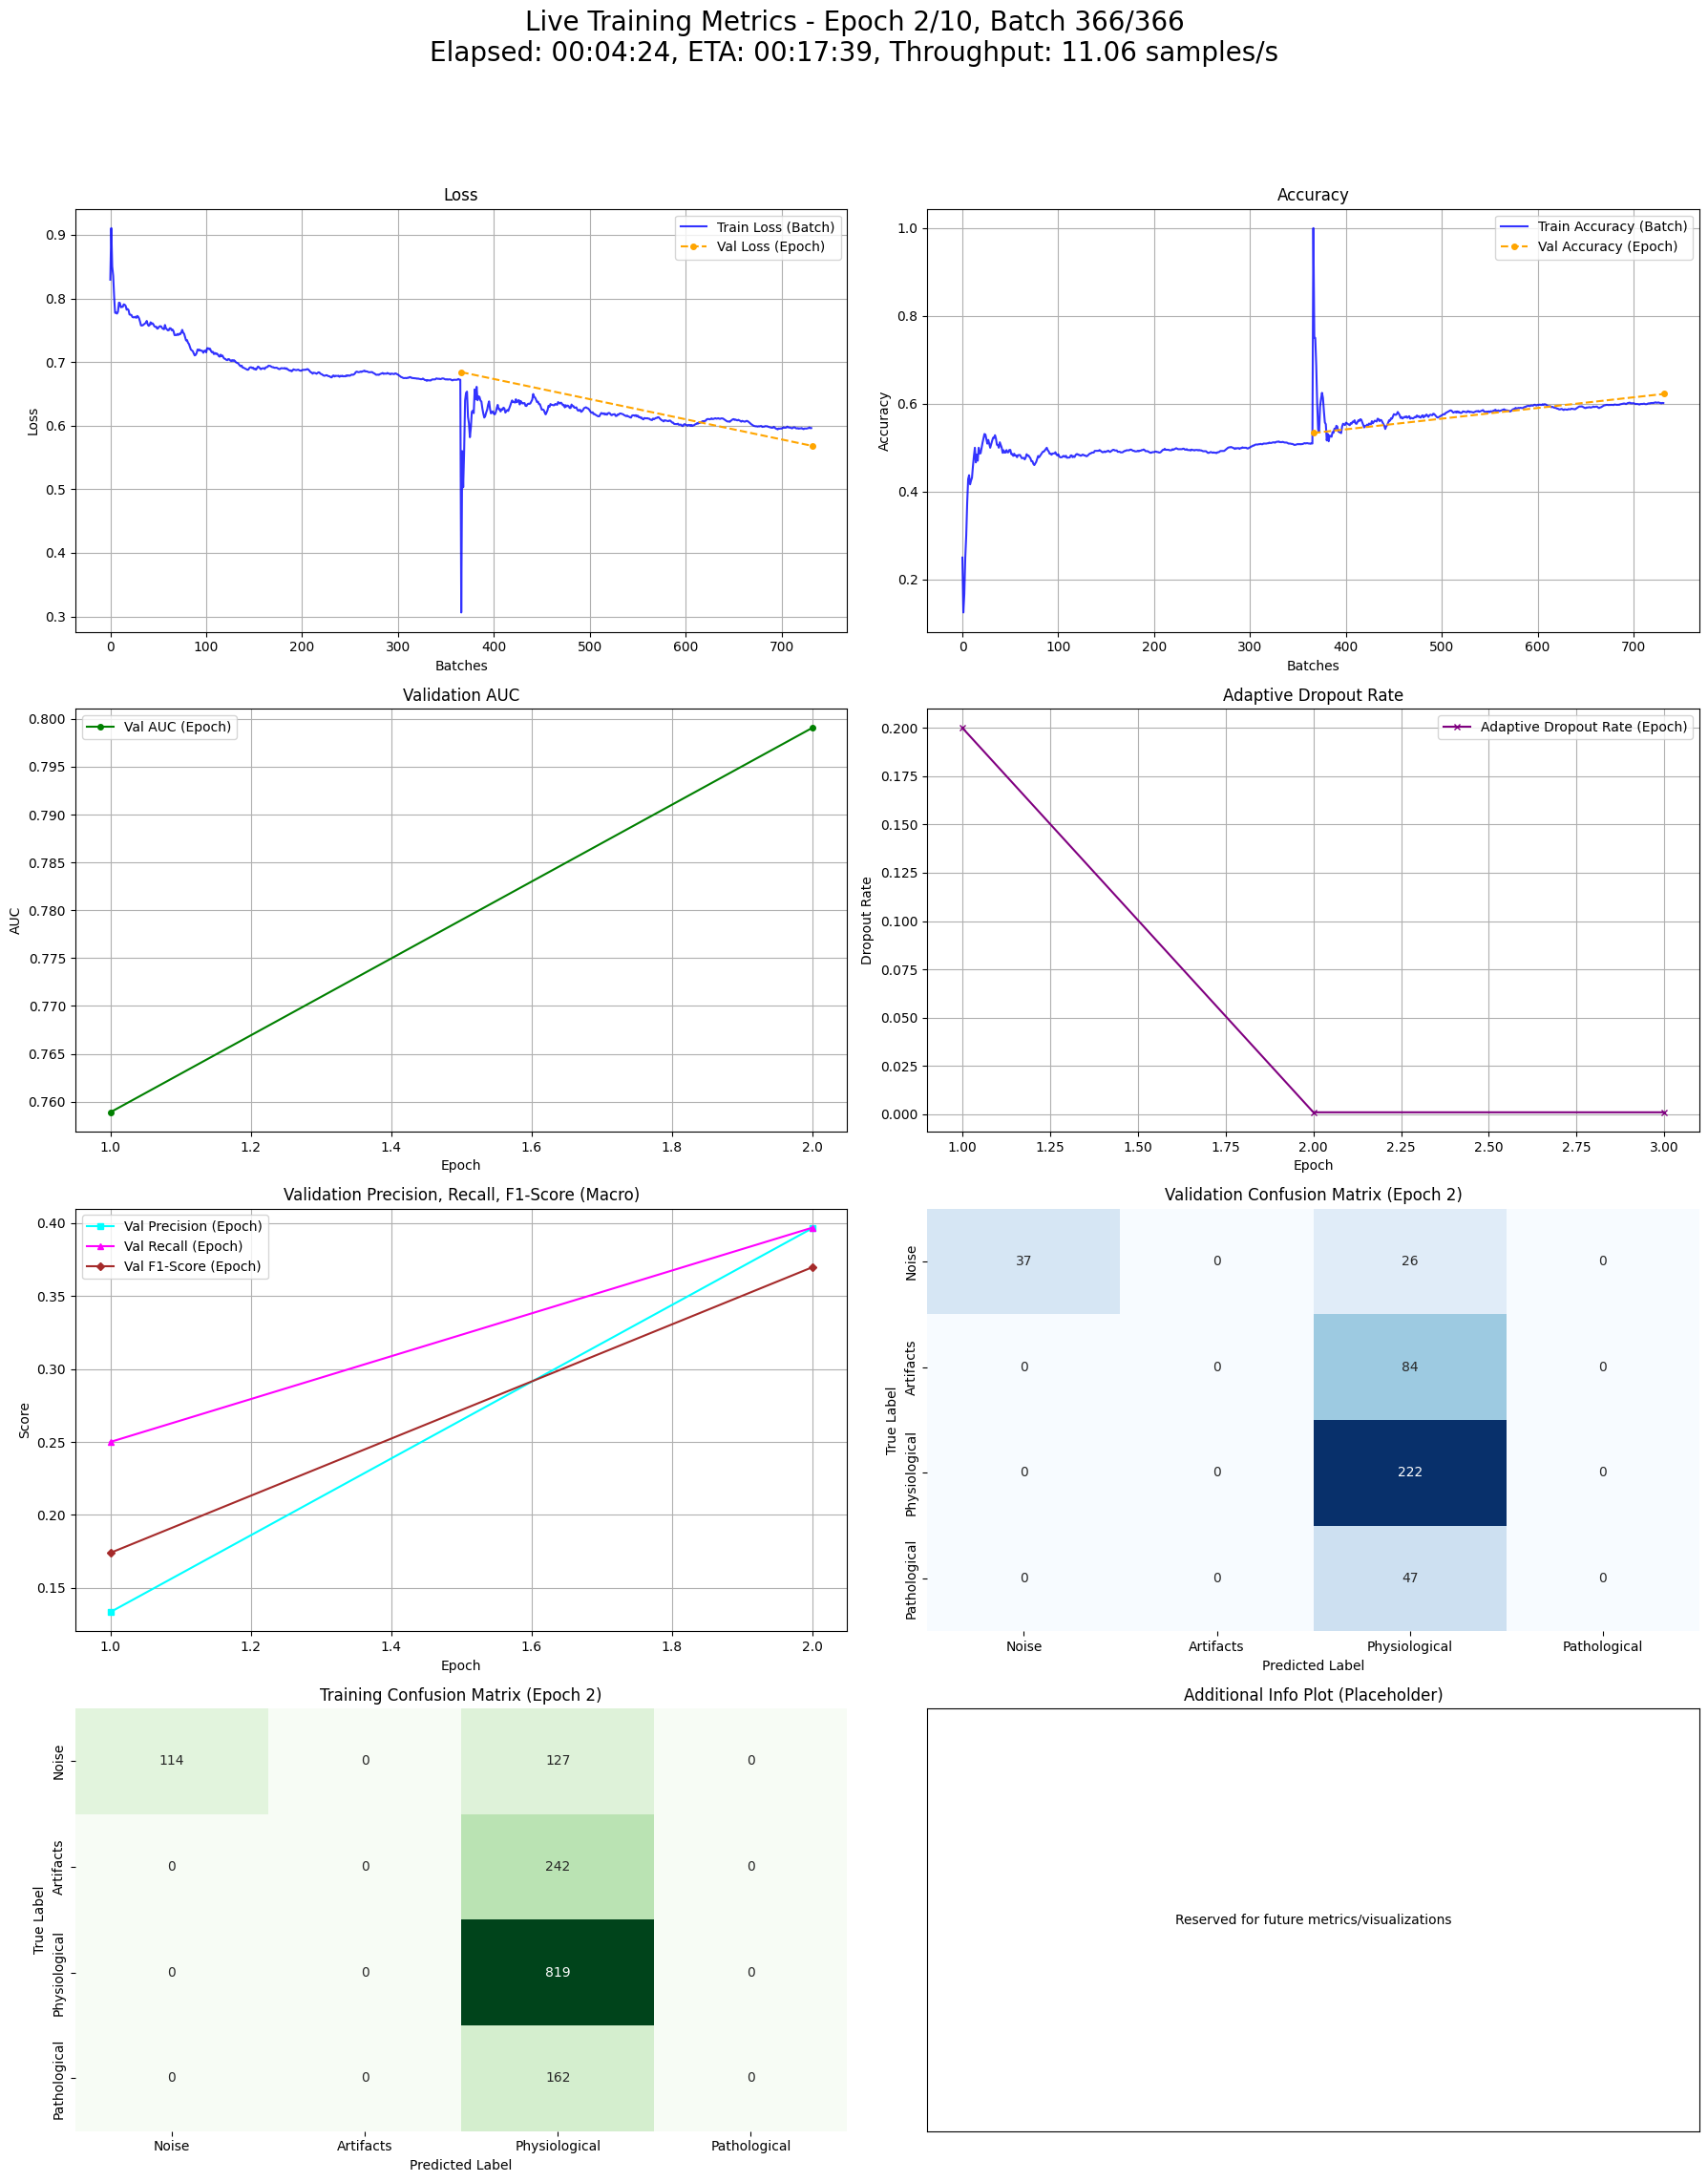

c:\Users\caspe\anaconda3\envs\SPIKEDETEC\lib\site-packages\keras\engine\training.py:2319: UserWarning: Metric F1ScoreMacro implements a `reset_states()` method; rename it to `reset_state()` (without the final "s"). The name `reset_states()` has been deprecated to improve API consistency.
  m.reset_state()



Epoch 3: Composite Score: -0.1296, New Dropout Rate: 0.0010
   (Val Acc: 0.6370, AUC: 0.8433, Val Loss: 0.5041, Rel Gap: 0.0110)


In [ ]:
# --- CONSOLIDATED IMPORTS ---
import os
import time
import json
import numpy as np
import h5py
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import random
import shutil
from datetime import datetime # Import datetime for unique timestamp
# TensorFlow Keras specific imports (part of tensorflow)
from tensorflow.keras import layers, metrics, Model
from tensorflow.keras.callbacks import Callback, EarlyStopping
# Scikit-learn metrics and utilities
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)
from sklearn.model_selection import train_test_split
# Jupyter/Kaggle specific utility for clearing output
from IPython.display import clear_output
from functools import partial

# ---------------------------
# Data Directories and Files
# ---------------------------
DATA_SAMPLE_PERCENTAGE = 0.01

dataset_dir = r'C:\DATA_EEG'
output_dir = r'C:\DATA_EEG\Dataset_Joined\TCN'
dir_path = os.path.join(dataset_dir, 'DataSet_Joined')
main_dataset_file = os.path.join(dataset_dir, 'Dataset_Joined', 'dataset.h5')


# Define paths for saving artifacts
MODEL_SAVE_PATH = os.path.join(output_dir, 'tcn_model.keras') # Keras native format
HISTORY_SAVE_PATH = os.path.join(output_dir, 'training_history.json')
PLOTS_SAVE_DIR = os.path.join(output_dir, 'training_plots')
CLASS_WEIGHTS_SAVE_PATH = os.path.join(output_dir, 'class_weights.json')
OPTIMAL_THRESHOLD_SAVE_PATH = os.path.join(output_dir, 'optimal_f1_threshold.json')

NUM_CLASSES = 4
INPUT_SEQUENCE_LENGTH = 15000 # Adjusted to user's specified length
epochs = 10
batch_size = 4 # Physical batch size
ACCUMULATION_STEPS = 2 # Number of physical batches to accumulate gradients over
INITIAL_LEARNING_RATE = 1e-3
L2_REGULARIZATION_LAMBDA = 1e-4

# TCN Hyperparameters
DILATED_CONV_FILTERS = 8
DILATED_CONV_KERNEL_SIZE = 2
DILATED_CONV_DILATION_RATES = [1, 2, 4, 8, 16] # Reduced from [1, 2, 4, 8, 16, 32, 64]
TCN_BLOCKS = 1 # The number of times to stack the TCN block structure

train_ratio = 0.7
val_ratio = 0.2
test_ratio = 0.1

AUGMENTATION_PROBABILITY = 0.0 # Data augmentation is now disabled
NOISE_AMPLITUDE = 0.01
SCALE_FACTOR_MIN = 0.98
SCALE_FACTOR_MAX = 1.005

EARLY_STOPPING_MONITOR = 'val_loss'
EARLY_STOPPING_PATIENCE = 3 # Reduced patience for faster training completion

INITIAL_DROPOUT_RATE = 0.2
MIN_DROPOUT_RATE = 0.001
MAX_DROPOUT_RATE = 0.7
DROPOUT_SCALING_FACTOR = 0.05
DROPOUT_BASELINE_GAP = 0.02

CLASS_NAMES = ["Noise", "Artifacts", "Physiological", "Pathological"]
PLOT_HISTORY_METRICS = ['loss', 'accuracy', 'auc', 'precision', 'recall', 'f1_score_macro']


USE_FOCAL_LOSS = True
FOCAL_LOSS_GAMMA = 2.0

OPTIMIZE_THRESHOLD_ON_VALIDATION = True
THRESHOLD_SEARCH_STEPS = 50

## keep above variables in this exact spot
# Ensure the plots save directory exists
# NEW: Control variable for dataset caching
USE_DATASET_CACHING = False # Set to False to disable caching and save memory

print('done')

os.makedirs(PLOTS_SAVE_DIR, exist_ok=True)



# ---------------------------
# Clear TensorFlow Dataset Caches (MORE ROBUST CLEANUP)
# ---------------------------
# Generate a unique timestamp for cache directories to avoid conflicts for new caches
unique_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S_%f")

# Define paths for dataset caches with unique suffixes for *new* caches
# These paths will only be used if USE_DATASET_CACHING is True
train_cache_filepath = os.path.join(output_dir, f'train_dataset_cache_{unique_timestamp}')
val_cache_filepath = os.path.join(output_dir, f'val_dataset_cache_{unique_timestamp}')
test_cache_filepath = os.path.join(output_dir, f'test_dataset_cache_{unique_timestamp}')

print("\n--- Performing aggressive cleanup of old dataset cache directories and lockfiles ---")
for item_name in os.listdir(output_dir):
    full_path = os.path.join(output_dir, item_name)
    
    # Check for directories that look like TF cache directories or any lockfiles
    if os.path.isdir(full_path) and ("_dataset_cache" in item_name or "dataset_cache" in item_name):
        try:
            shutil.rmtree(full_path)
            print(f"Removed old cache directory: {full_path}")
        except OSError as e:
            print(f"Error removing old cache directory {full_path}: {e}")
    # Check for any .lockfile
    elif item_name.endswith('.lockfile'):
        try:
            os.remove(full_path)
            print(f"Removed old cache lockfile: {full_path}")
        except OSError as e:
            print(f"Error removing old cache lockfile {full_path}: {e}")
print("--- Aggressive cleanup complete ---")

# ---------------------------
# TPU Detection and Strategy Initialization (Removed for local execution, still included for context)
# ---------------------------
# The following TPU setup is commented out as requested to avoid issues,
# but it's kept for reference if you ever return to TPU training.
# try:
#     tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
#     print('Running on TPU ', tpu.cluster_spec().as_dict()['worker'])
#     tf.config.experimental_connect_to_cluster(tpu)
#     tf.tpu.experimental.initialize_tpu_system(tpu)
#     strategy = tf.distribute.TPUStrategy(tpu)
# except ValueError:
#     print('Not running on TPU, trying to run on GPU or CPU...')
strategy = tf.distribute.get_strategy() # Default strategy for CPU and single GPU
print('Number of accelerators: {}'.format(strategy.num_replicas_in_sync))


# ---------------------------
# Custom Swish Activation Layer - NEW IMPLEMENTATION
# ---------------------------
class SwishActivation(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(SwishActivation, self).__init__(**kwargs)

    def call(self, x):
        """
        Implements the Swish activation function: x * sigmoid(x).
        This is now a proper Keras layer to ensure compatibility with KerasTensors.
        """
        return x * tf.sigmoid(x)

    def get_config(self):
        return super(SwishActivation, self).get_config()

# ---------------------------
# Custom F1-Score Metric (Macro Average)
# ---------------------------
class F1ScoreMacro(tf.keras.metrics.Metric):
    """
    Custom Keras Metric for calculating the Macro F1-Score for multi-class classification.
    This metric sums True Positives, False Positives, and False Negatives per class
    over batches and then calculates the F1-score for each class before averaging them.
    """
    def __init__(self, num_classes, name='f1_score_macro', **kwargs):
        super(F1ScoreMacro, self).__init__(name=name, **kwargs)
        self.num_classes = num_classes
        # Initialize internal variables for TP, FP, FN for each class
        # These are tf.Variable objects and will be reset by Keras when reset_states is called
        self.tp = self.add_weight(name='tp', shape=(num_classes,), initializer='zeros', dtype=tf.float32)
        self.fp = self.add_weight(name='fp', shape=(num_classes,), initializer='zeros', dtype=tf.float32)
        self.fn = self.add_weight(name='fn', shape=(num_classes,), initializer='zeros', dtype=tf.float32)

    def update_state(self, y_true, y_pred, sample_weight=None):
        # Cast inputs to the metric's dtype
        y_true = tf.cast(y_true, self.dtype)
        y_pred = tf.cast(y_pred, self.dtype)

        # Convert one-hot encoded labels to sparse (integer) labels for argmax
        y_true_labels = tf.argmax(y_true, axis=-1)
        y_pred_labels = tf.argmax(y_pred, axis=-1)

        # Create one-hot encoded versions of the predicted labels
        # This is essential for element-wise multiplication to count TP, FP, FNGx per class
        y_pred_one_hot = tf.one_hot(y_pred_labels, depth=self.num_classes, dtype=self.dtype)

        # Calculate True Positives (TP) per class: y_true == 1 AND y_pred == 1
        current_tp = tf.reduce_sum(y_true * y_pred_one_hot, axis=0)
        
        # Calculate False Positives (FP) per class: y_true == 0 AND y_pred == 1
        current_fp = tf.reduce_sum((1 - y_true) * y_pred_one_hot, axis=0)

        # Calculate False Negatives (FN) per class: y_true == 1 AND y_pred == 0
        current_fn = tf.reduce_sum(y_true * (1 - y_pred_one_hot), axis=0)
        
        # Assign values to the state variables
        self.tp.assign_add(current_tp)
        self.fp.assign_add(current_fp)
        self.fn.assign_add(current_fn)

    def result(self):
        # Add epsilon to denominators to prevent division by zero
        epsilon = tf.keras.backend.epsilon()
        
        # Calculate Precision per class
        precision_per_class = self.tp / (self.tp + self.fp + epsilon)
        
        # Calculate Recall per class
        recall_per_class = self.tp / (self.tp + self.fn + epsilon)

        # Calculate F1-score per class
        f1_per_class = 2 * (precision_per_class * recall_per_class) / (precision_per_class + recall_per_class + epsilon)

        # Macro F1-score is the unweighted average of F1-scores across all classes
        return tf.reduce_mean(f1_per_class)

    def reset_states(self):
        # Reset all internal variables to their initial (zero) state
        # The base class's reset_states calls this for each `self.add_weight` variable
        self.tp.assign(tf.zeros_like(self.tp))
        self.fp.assign(tf.zeros_like(self.fp))
        self.fn.assign(tf.zeros_like(self.fn))

    def get_config(self):
        config = super(F1ScoreMacro, self).get_config()
        config.update({'num_classes': self.num_classes})
        return config

# ---------------------------
# 1. Enable GPU Usage and Optimizations
# ---------------------------
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Using GPU: {gpus[0].name}")
    except RuntimeError as e:
        print(e)
else:
    print("No GPU found, using CPU.")

# Enable mixed precision
tf.keras.mixed_precision.set_global_policy('mixed_float16')
start_time = time.time() # This is the global start_time we need

# ---------------------------
# Custom Focal Loss Function
# ---------------------------
def focal_loss_fn(y_true, y_pred, gamma=2.0, alpha_weights=None):
    """
    Custom implementation of Focal Loss for multi-class classification.
    Args:
        y_true (tf.Tensor): True labels (one-hot encoded).
        y_pred (tf.Tensor): Predicted probabilities (after softmax).
        gamma (float): Focusing parameter. Higher gamma reduces the loss for
                       well-classified examples, focusing on hard examples.
        alpha_weights (tf.Tensor or None): Class-specific weighting factor.
                                           If None, all classes are weighted equally.
                                           Should be a tensor of shape (NUM_CLASSES,).
    Returns:
        tf.Tensor: Computed focal loss.
    """
    epsilon = tf.keras.backend.epsilon()
    y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon) # Clip to prevent log(0)
    # Calculate cross-entropy
    cross_entropy = -y_true * tf.math.log(y_pred)
    # Calculate p_t (probability of the true class)
    # y_true is one-hot, so y_true * y_pred gives 0 for incorrect classes and y_pred for true class
    p_t = tf.reduce_sum(y_true * y_pred, axis=-1, keepdims=True)
    # Calculate modulating factor (1 - p_t)^gamma
    modulating_factor = tf.pow(1.0 - p_t, gamma)
    # Apply alpha weights if provided
    if alpha_weights is not None:
        # Reshape alpha_weights to match y_true/y_pred for element-wise multiplication
        # alpha_weights should be (batch_size, NUM_CLASSES) if using y_true directly for indexing
        # Or (NUM_CLASSES,) for broadcastable multiplication
        alpha_factor = tf.reduce_sum(y_true * alpha_weights, axis=-1, keepdims=True)
        focal_loss = alpha_factor * modulating_factor * cross_entropy
    else:
        focal_loss = modulating_factor * cross_entropy
    return tf.reduce_sum(focal_loss, axis=-1) # Sum across classes for each sample

# --- IMPORTANT: Register your custom focal_loss_fn ---
# This makes Keras aware of your custom loss function by name, allowing it to be
# serialized correctly when you save your model.
tf.keras.utils.get_custom_objects().update({'focal_loss_fn': focal_loss_fn})


# ---------------------------
# HDF5 Generator (Modified for global shuffling)
# ---------------------------
def hdf5_generator(file_path, shuffled_keys_for_split):
    """
    A Python generator function to efficiently load and preprocess data
    from an HDF5 file based on a pre-shuffled list of keys.
    It yields normalized data tensors and one-hot encoded labels.
    Args:
        file_path (str): The path to the main HDF5 file (dataset.h5).
        shuffled_keys_for_split (list): A list of (label_str, file_name) tuples
                                        representing the samples for this specific split,
                                        already globally shuffled.
    Yields:
        tuple: A tuple containing:
            - tf.Tensor: The preprocessed data (normalized float32).
            - tf.Tensor: The integer label (int64).
    """
    # Open the HDF5 file once for the duration of the generator's existence
    with h5py.File(file_path, 'r') as hdf5_file:
        for label_str, file_name in shuffled_keys_for_split:
            dataset_key = f"{label_str}/{file_name}"
            if dataset_key not in hdf5_file:
                # print(f"Warning: Dataset key '{dataset_key}' not found in HDF5 file. Skipping.") # Uncomment for debugging
                continue
            try:
                # Load data, convert to float32, and normalize (Z-score)
                data = hdf5_file[dataset_key][:].astype(np.float32)
                data = (data - np.mean(data)) / (np.std(data) + 1e-8) # Add epsilon for stability
                int_label = int(label_str.split('_')[-1])
                # Yield data and label as TensorFlow tensors
                yield tf.convert_to_tensor(data.reshape((1, INPUT_SEQUENCE_LENGTH, 1)), dtype=tf.float32), \
                      tf.convert_to_tensor(np.array([int_label]), dtype=tf.int64)
            except Exception as e:
                print(f"HDF5 generator error for {dataset_key}: {e}. Skipping sample.")
                continue
    # The generator will exit when all keys in shuffled_keys_for_split have been processed.
    # The .repeat() on the dataset will then cause it to restart from the beginning of the shuffled keys.

# ---------------------------
# Preprocessing Functions
# ---------------------------
def reshape_input(x, y):
    """
    Reshapes the input tensor `x` by removing a singular dimension (axis=1).
    This is often needed when the generator yields data with an extra batch dimension.
    Args:
        x (tf.Tensor): The input data tensor.
        y (tf.Tensor): The label tensor.
    Returns:
        tuple: Reshaped x and original y.
    """
    return tf.squeeze(x, axis=1), y

def one_hot_encode_labels(x, y):
    """
    Converts integer labels `y` into one-hot encoded vectors.
    Args:
        x (tf.Tensor): The input data tensor.
        y (tf.Tensor): The integer label tensor.
    Returns:
        tuple: Original x and one-hot encoded y.
    """
    # Squeeze y to remove any singular dimensions before one-hot encoding
    y_one_hot = tf.one_hot(tf.squeeze(y, axis=-1), depth=NUM_CLASSES, dtype=tf.float32)
    return x, y_one_hot

# ---------------------------
# Data Augmentation Function (MODIFIED for 35% chance and wider range)
# ---------------------------
def apply_augmentation(x, y): # Removed probability parameter, now uses global AUGMENTATION_PROBABILITY
    """
    Adds random Gaussian noise and applies random amplitude scaling to the input
    time-series data with a given probability.
    Args:
        x (tf.Tensor): The input data tensor (time-series).
        y (tf.Tensor): The label tensor.
    Returns:
        tuple: Augmented x or original x, and original y.
    """
    def augment_true():
        # 1. Add Random Gaussian Noise
        noise = tf.random.normal(shape=tf.shape(x), mean=0.0, stddev=NOISE_AMPLITUDE, dtype=tf.float32)
        augmented_x = x + noise
        # 2. Random Amplitude Scaling
        scale_factor = tf.random.uniform(shape=[], minval=SCALE_FACTOR_MIN, maxval=SCALE_FACTOR_MAX, dtype=tf.float32)
        augmented_x = augmented_x * scale_factor
        return augmented_x

    def augment_false():
        return x # Return original x if augmentation is not applied

    # Generate a random uniform number
    rand_val = tf.random.uniform(shape=[], minval=0.0, maxval=1.0, dtype=tf.float32)
    # Conditionally apply augmentation based on the random number
    augmented_x = tf.cond(rand_val < AUGMENTATION_PROBABILITY, augment_true, augment_false)
    return augmented_x, y

# ---------------------------
# Dataset Creation (Modified for Caching and Parallelism)
# ---------------------------
def create_tf_dataset(file_path, batch_size, shuffled_keys_for_split, augment=False,
                      use_cache=USE_DATASET_CACHING, cache_filepath=None):
    """
    Creates a TensorFlow Dataset from the HDF5 generator, applying batching
    and preprocessing steps. Shuffling is handled by the pre-shuffled keys list.
    
    Args:
        file_path (str): The path to the main HDF5 file (dataset.h5).
        batch_size (int): The number of samples per batch.
        shuffled_keys_for_split (list): A list of (label_str, file_name) tuples
                                        representing the samples for this specific split,
                                        already globally shuffled.
        augment (bool): Whether to apply data augmentation. Set to True for training data.
        use_cache (bool): If True, caches the dataset elements after the generator.
                          Now defaults to the global USE_DATASET_CACHING variable.
        cache_filepath (str, optional): Path to a file for disk caching. If None, caches in memory.
                                        Only used if use_cache is True.
    
    Returns:
        tf.data.Dataset: A configured TensorFlow Dataset ready for training/evaluation.
    """

    # Define conservative values
    # These can be tuned: start low, then increase if stable.
    # A common starting point is num_CPU_cores or a small integer.
    # For Kaggle with shared resources, even 2-4 might be better than AUTOTUNE if OOM.
    _fixed_num_parallel_calls = 2  # Or try 2, or tf.data.experimental.AUTOTUNE.num_cpu_cores if available
    _fixed_prefetch_buffer_size = 2  # Or 1, or tf.data.AUTOTUNE

    dataset = tf.data.Dataset.from_generator(
        lambda: hdf5_generator(file_path, shuffled_keys_for_split),
        output_signature=(
            tf.TensorSpec(shape=(1, INPUT_SEQUENCE_LENGTH, 1), dtype=tf.float32),
            tf.TensorSpec(shape=(1,), dtype=tf.int64)
        )
    )

    if use_cache:
        if cache_filepath:
            print(f"Caching dataset to disk at: {cache_filepath}")
            dataset = dataset.cache(cache_filepath)
        else:
            print("Caching dataset in memory.")
            dataset = dataset.cache()

    dataset = dataset.batch(batch_size).repeat()

    if augment:
        dataset = dataset.map(apply_augmentation, num_parallel_calls=_fixed_num_parallel_calls)

    dataset = dataset.map(reshape_input, num_parallel_calls=_fixed_num_parallel_calls)
    dataset = dataset.map(one_hot_encode_labels, num_parallel_calls=_fixed_num_parallel_calls)

    return dataset.prefetch(_fixed_prefetch_buffer_size)  # Use fixed prefetch size here


# ---------------------------
# Adaptive Dropout & Metric Logging Callback (MODIFIED FOR COMPOSITE SCORE)
# ---------------------------
class MetricsAndAdaptiveDropout(tf.keras.callbacks.Callback):
    """
    A custom Keras Callback that dynamically adjusts the dropout rate
    based on a composite score derived from multiple model performance metrics
    (validation accuracy, AUC, validation loss, and train/val accuracy gap).
    It also logs metrics to the console and passes dropout rate to a plotter.
    """
    def __init__(self, validation_data, verbose=0, initial_dropout=INITIAL_DROPOUT_RATE, min_dropout=MIN_DROPOUT_RATE, max_dropout=MAX_DROPOUT_RATE,
                     scaling_factor=DROPOUT_SCALING_FACTOR, baseline_gap=DROPOUT_BASELINE_GAP,
                     plotter_callback=None):
        super().__init__()
        self.validation_data_arg = validation_data
        self.verbose = verbose
        self.initial_dropout = initial_dropout
        self.min_dropout = min_dropout
        self.max_dropout = max_dropout
        self.scaling_factor = scaling_factor
        self.baseline_gap = baseline_gap # Used for the relative_gap component
        # Initialize previous values for metric comparison to calculate impact
        self.previous_val_acc = 0.0
        self.previous_auc = 0.0
        self.previous_val_loss = float('inf') # Start with a high loss
        self.current_dropout_rate = initial_dropout
        self.dropout_layer = None
        self.dropout_rate_history = []
        self.plotter_callback = plotter_callback

    def on_train_begin(self, logs=None):
        # Find the first dropout layer in the model to control its rate
        for layer in self.model.layers:
            # Check if the layer is a functional API layer or a sequential layer
            if hasattr(layer, 'layers'): # For functional API models, layers might be nested
                for sub_layer in layer.layers:
                    if isinstance(sub_layer, tf.keras.layers.Dropout):
                        self.dropout_layer = sub_layer
                        break
            if isinstance(layer, tf.keras.layers.Dropout): # For simple sequential models
                self.dropout_layer = layer
                break
        
        if self.dropout_layer is None:
            print("Warning: No Dropout layer found for AdaptiveDropout. Adaptive dropout will not function.")
        else:
            self.dropout_layer.rate = self.initial_dropout
            self.current_dropout_rate = self.initial_dropout
            if self.verbose > 0:
                print(f"Initial dropout rate set to: {self.initial_dropout:.4f}")
        self.dropout_rate_history.append(self.current_dropout_rate)
        if self.plotter_callback:
            self.plotter_callback.log_dropout_rate(self.current_dropout_rate)

    def on_epoch_end(self, epoch, logs=None):
        if self.dropout_layer is None:
            return
        logs = logs or {}
        train_acc = logs.get('accuracy', 0.0) # Training accuracy for relative gap
        val_acc = logs.get('val_accuracy', 0.0)
        auc = logs.get('val_auc', 0.0)
        val_loss = logs.get('val_loss', float('inf'))
        # Add a small epsilon to denominator to prevent division by zero
        relative_gap = (train_acc - val_acc) / max(train_acc, 1e-8) if train_acc > 0 else 0.0
        # Calculate the absolute difference first for clarity or reuse
        abs_val_acc_diff = abs(val_acc - self.previous_val_acc)
        # Now use it in the conditional assignment
        val_no_learn = abs_val_acc_diff if abs_val_acc_diff > 0.01 else 20
        # Calculate the impact of changes in metrics from the previous epoch
        # Positive impact value means metric is worsening (e.g., val_acc decreased, val_loss increased)
        # We want to increase dropout if performance worsens, so signs are chosen accordingly.
        val_acc_impact = (self.previous_val_acc - val_acc) * 1.5
        auc_impact = (self.previous_auc - auc) * 0.8
        val_loss_impact = (val_loss - self.previous_val_loss) * 1.0
        val_no_learn_impact = (val_no_learn)/25
        # Calculate the composite score
        composite_score = (
            val_acc_impact +
            auc_impact +
            val_loss_impact +
            (relative_gap - self.baseline_gap)+ # If relative gap is too high, this term increases score
            val_no_learn_impact
        )
        # Update dropout rate based on the composite score
        new_dropout = self.current_dropout_rate + (composite_score * self.scaling_factor)
        # Clip the new dropout rate within the defined min and max bounds
        new_dropout = min(max(new_dropout, self.min_dropout), self.max_dropout)
        # Update the dropout layer's rate
        self.dropout_layer.rate = new_dropout
        self.current_dropout_rate = new_dropout
        # Update previous metric values for the next epoch's calculation
        self.previous_val_acc = val_acc
        self.previous_auc = auc
        self.previous_val_loss = val_loss
        # Log the current dropout rate and update the plotter callback
        self.dropout_rate_history.append(self.current_dropout_rate)
        if self.plotter_callback:
            self.plotter_callback.log_dropout_rate(self.current_dropout_rate)
        if self.verbose > 0:
            print(f"\nEpoch {epoch+1}: Composite Score: {composite_score:.4f}, New Dropout Rate: {self.current_dropout_rate:.4f}")
            print(f"   (Val Acc: {val_acc:.4f}, AUC: {auc:.4f}, Val Loss: {val_loss:.4f}, Rel Gap: {relative_gap:.4f})")

    def get_config(self):
        config = super().get_config()
        config.update({
            'initial_dropout': float(self.initial_dropout),
            'min_dropout': float(self.min_dropout),
            'max_dropout': float(self.max_dropout),
            'scaling_factor': float(self.scaling_factor),
            'baseline_gap': float(self.baseline_gap),
        })
        return config

# ---------------------------
# Live Plotting Callback (Modified for batch-level plotting and separate saving)
# ---------------------------
class BatchMetricsPlotter(tf.keras.callbacks.Callback):
    """
    A Keras Callback for live plotting of training and validation metrics.
    Metrics are plotted per batch for training, and per epoch for validation.
    Includes Loss, Accuracy, AUC, Adaptive Dropout Rate, Precision, Recall, F1-Score, and Confusion Matrix.
    """
    def __init__(self, num_classes=NUM_CLASSES, val_dataset=None, validation_steps=None,
                     class_names=CLASS_NAMES, start_time=None, batch_size=None, steps_per_epoch=None, total_epochs=None,
                     plot_every_n_batches=PLOT_EVERY_N_BATCHES, train_dataset=None): # Added train_dataset
        super().__init__()
        self.batch_count = 0
        self.current_epoch = 0
        self.num_classes = num_classes
        self.val_dataset = val_dataset
        self.train_dataset = train_dataset # Store train_dataset
        self.validation_steps = validation_steps
        self.steps_per_epoch = steps_per_epoch # Also need steps_per_epoch for training CM
        self.class_names = class_names if class_names is not None else [str(i) for i in range(num_classes)]
        self.start_time = start_time if start_time is not None else time.time()
        self.batch_size = batch_size
        self.steps_per_epoch = steps_per_epoch
        self.total_epochs = total_epochs
        self.plot_every_n_batches = plot_every_n_batches # Store the interval
        self.train_loss_history = []
        self.train_accuracy_history = []
        self.val_loss_history = []
        self.val_accuracy_history = []
        self.val_auc_history = []
        self.dropout_rate_history = [] # To be populated by AdaptiveDropout callback
        self.val_precision_history = []
        self.val_recall_history = []
        self.val_f1_score_history = []
        self.confusion_matrix_history = []
        self.train_confusion_matrix_history = [] # New: for training confusion matrix
        plt.ion() # Enable interactive plotting

    def on_epoch_begin(self, epoch, logs=None):
        self.current_epoch = epoch + 1
        # NOT clearing train_confusion_matrix_history here as requested
        # self.train_confusion_matrix_history = [] # REMOVED THIS LINE
        # This means the last epoch's training CM will persist until the new epoch completes.

    def on_train_batch_end(self, batch, logs=None):
        logs = logs or {}
        self.batch_count += 1
        self.train_loss_history.append(logs.get('loss', 0))
        self.train_accuracy_history.append(logs.get('accuracy', 0))
        # Plot only if it's time to plot
        if self.batch_count % self.plot_every_n_batches == 0:
            self._update_plot(is_batch_plot=True) # Pass flag to indicate batch plot

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        self.val_loss_history.append(logs.get('val_loss', 0))
        self.val_accuracy_history.append(logs.get('val_accuracy', 0))
        self.val_auc_history.append(logs.get('val_auc', 0))
        self.current_epoch = epoch + 1
        val_true_labels_epoch = []
        val_predicted_probs_epoch = []
        if self.model and self.val_dataset and self.validation_steps:
            val_data_iterator = iter(self.val_dataset)
            for _ in range(self.validation_steps):
                try:
                    val_x_batch, val_y_true_batch = next(val_data_iterator)
                    val_predicted_probs_batch = self.model.predict(val_x_batch, verbose=0)
                    val_true_labels_epoch.extend(tf.argmax(val_y_true_batch, axis=-1).numpy())
                    val_predicted_probs_epoch.extend(val_predicted_probs_batch)
                except tf.errors.OutOfRangeError:
                    print("Warning: Validation dataset exhausted prematurely during epoch end prediction.")
                    break
        if val_true_labels_epoch and val_predicted_probs_epoch:
            y_true_np = np.array(val_true_labels_epoch)
            y_pred_probs_np = np.array(val_predicted_probs_epoch)
            y_pred_classes_np = np.argmax(y_pred_probs_np, axis=-1)
            cm = confusion_matrix(y_true_np, y_pred_classes_np, labels=np.arange(self.num_classes))
            self.confusion_matrix_history.append(cm)
            macro_precision = precision_score(y_true_np, y_pred_classes_np, average='macro', zero_division=0)
            macro_recall = recall_score(y_true_np, y_pred_classes_np, average='macro', zero_division=0)
            macro_f1 = f1_score(y_true_np, y_pred_classes_np, average='macro', zero_division=0)
            self.val_precision_history.append(macro_precision)
            self.val_recall_history.append(macro_recall)
            self.val_f1_score_history.append(macro_f1)
        else:
            self.confusion_matrix_history.append(np.zeros((self.num_classes, self.num_classes), dtype=int))
            self.val_precision_history.append(0.0)
            self.val_recall_history.append(0.0)
            self.val_f1_score_history.append(0.0)
        # New: Collect data and generate confusion matrix for training dataset at epoch end
        train_true_labels_epoch = []
        train_predicted_probs_epoch = []
        if self.model and self.train_dataset and self.steps_per_epoch:
            # Create a temporary iterator for one full pass over the training data for CM
            train_data_iterator_cm = iter(self.train_dataset.unbatch().batch(self.batch_size).take(self.steps_per_epoch))
            for _ in range(self.steps_per_epoch):
                try:
                    train_x_batch, train_y_true_batch = next(train_data_iterator_cm)
                    train_predicted_probs_batch = self.model.predict(train_x_batch, verbose=0)
                    train_true_labels_epoch.extend(tf.argmax(train_y_true_batch, axis=-1).numpy())
                    train_predicted_probs_epoch.extend(train_predicted_probs_batch)
                except tf.errors.OutOfRangeError:
                    print("Warning: Training dataset exhausted prematurely during epoch end training CM prediction.")
                    break
        if train_true_labels_epoch and train_predicted_probs_epoch:
            train_y_true_np = np.array(train_true_labels_epoch)
            train_y_pred_probs_np = np.array(train_predicted_probs_epoch)
            train_y_pred_classes_np = np.argmax(train_y_pred_probs_np, axis=-1)
            train_cm = confusion_matrix(train_y_true_np, train_y_pred_classes_np, labels=np.arange(self.num_classes))
            self.train_confusion_matrix_history.append(train_cm)
        else:
            self.train_confusion_matrix_history.append(np.zeros((self.num_classes, self.num_classes), dtype=int))
        # Trigger a final plot update at the end of the epoch to show latest validation metrics
        self._update_plot(is_batch_plot=False) # Pass flag to indicate epoch plot

    def on_train_end(self, logs=None):
        # Save the final plot and individual subplots
        self._update_plot(final_save=True)
        plt.ioff() # Turn off interactive mode at the end of training
        plt.close('all') # Close all plot windows

    def log_dropout_rate(self, dropout_rate):
        """
        Method to receive and store the dropout rate from the AdaptiveDropout callback.
        """
        self.dropout_rate_history.append(dropout_rate)

    def _update_plot(self, is_batch_plot=True, final_save=False):
        """
        Clears the output and redraws the plot with 8 subplots (4x2 layout),
        showing batch-level training metrics, epoch-level validation metrics,
        adaptive dropout rate, and confusion matrix, along with a progress bar.
        If final_save is True, saves the plots to files.
        """
        if not final_save:
            clear_output(wait=True) # Clear previous plot output
            fig, axes = plt.subplots(4, 2, figsize=(18, 24)) # Increased height for 4 rows
            axes = axes.flatten() # Flatten for easier indexing
        else:
            # If final_save, we will create new figures for each plot
            pass # No need to create a multi-subplot figure for final save in this block

        # Calculate dynamic stats for the title
        elapsed_seconds = time.time() - self.start_time
        total_samples_processed = self.batch_count * self.batch_size if self.batch_size is not None else 0
        samples_per_second = total_samples_processed / elapsed_seconds if elapsed_seconds > 0 else 0
        
        # Format elapsed time
        el_h = int(elapsed_seconds // 3600)
        el_m = int((elapsed_seconds % 3600) // 60)
        el_s = int(elapsed_seconds % 60)
        elapsed_formatted = f'{el_h:02d}:{el_m:02d}:{el_s:02d}'
        
        # Calculate estimated remaining time (ETA)
        eta_str = ""
        if self.steps_per_epoch and self.total_epochs and self.batch_size and samples_per_second > 0:
            total_batches = self.steps_per_epoch * self.total_epochs
            batches_remaining = total_batches - self.batch_count
            if batches_remaining > 0:
                estimated_remaining_seconds = batches_remaining * self.batch_size / samples_per_second
                rem_h = int(estimated_remaining_seconds // 3600)
                rem_m = int((estimated_remaining_seconds % 3600) // 60)
                rem_s = int(estimated_remaining_seconds % 60)
                eta_str = f', ETA: {rem_h:02d}:{rem_m:02d}:{rem_s:02d}'
            else:
                eta_str = ', ETA: 00:00:00'
        
        current_batch_in_epoch = (self.batch_count - 1) % self.steps_per_epoch + 1
        plot_title_suffix = f'Epoch {self.current_epoch}/{self.total_epochs}, Batch {current_batch_in_epoch}/{self.steps_per_epoch}\nElapsed: {elapsed_formatted}{eta_str}, Throughput: {samples_per_second:.2f} samples/s'

        # Function to plot and save a single subplot
        def plot_and_save_single(fig_idx, filename_base, title_suffix, plot_data_fn):
            fig, ax = plt.subplots(figsize=(9, 6)) # Adjust size as needed
            plot_data_fn(ax) # Call the function to populate the plot
            ax.set_title(f'{filename_base.replace("_", " ").title()} ({title_suffix})')
            plt.savefig(os.path.join(PLOTS_SAVE_DIR, f'{filename_base}.png'), bbox_inches='tight')
            plt.close(fig) # Close the figure to free memory
            print(f"Plot saved: {filename_base}.png")


        # --- Plotting logic for real-time display ---
        if not final_save:
            fig.suptitle(f'Live Training Metrics - {plot_title_suffix}', fontsize=20)
            
            # Plot 1: Loss
            axes[0].plot(self.train_loss_history, label='Train Loss (Batch)', color='blue', alpha=0.8)
            if self.val_loss_history:
                val_x = np.arange(1, len(self.val_loss_history) + 1) * self.steps_per_epoch
                axes[0].plot(val_x, self.val_loss_history, label='Val Loss (Epoch)', color='orange', linestyle='--', marker='o', markersize=4)
            axes[0].set_title('Loss')
            axes[0].set_xlabel('Batches')
            axes[0].set_ylabel('Loss')
            axes[0].legend()
            axes[0].grid(True)
            
            # Plot 2: Accuracy
            axes[1].plot(self.train_accuracy_history, label='Train Accuracy (Batch)', color='blue', alpha=0.8)
            if self.val_accuracy_history:
                val_x = np.arange(1, len(self.val_accuracy_history) + 1) * self.steps_per_epoch
                axes[1].plot(val_x, self.val_accuracy_history, label='Val Accuracy (Epoch)', color='orange', linestyle='--', marker='o', markersize=4)
            axes[1].set_title('Accuracy')
            axes[1].set_xlabel('Batches')
            axes[1].set_ylabel('Accuracy')
            axes[1].legend()
            axes[1].grid(True)
            
            # Plot 3: Validation AUC (Epoch-level)
            if self.val_auc_history:
                axes[2].plot(np.arange(len(self.val_auc_history)) + 1, self.val_auc_history, label='Val AUC (Epoch)', color='green', marker='o', markersize=4)
                axes[2].set_title('Validation AUC')
                axes[2].set_xlabel('Epoch')
                axes[2].set_ylabel('AUC')
                axes[2].legend()
                axes[2].grid(True)
            else:
                axes[2].set_title('Validation AUC (Epoch-End Only)')
                axes[2].text(0.5, 0.5, 'Data available after epoch 1',
                                     horizontalalignment='center', verticalalignment='center', transform=axes[2].transAxes)
            
            # Plot 4: Adaptive Dropout Rate (Epoch-level)
            if self.dropout_rate_history:
                axes[3].plot(np.arange(len(self.dropout_rate_history)) + 1, self.dropout_rate_history, label='Adaptive Dropout Rate (Epoch)', color='purple', marker='x', markersize=4)
                axes[3].set_title('Adaptive Dropout Rate')
                axes[3].set_xlabel('Epoch')
                axes[3].set_ylabel('Dropout Rate')
                axes[3].legend()
                axes[3].grid(True)
            else:
                axes[3].set_title('Adaptive Dropout Rate (Epoch-End Only)')
                axes[3].text(0.5, 0.5, 'Data available after epoch 1',
                                     horizontalalignment='center', verticalalignment='center', transform=axes[3].transAxes)
            
            # Plot 5: Precision, Recall, F1-Score (Epoch-level)
            if self.val_precision_history:
                axes[4].plot(np.arange(len(self.val_precision_history)) + 1, self.val_precision_history, label='Val Precision (Epoch)', color='cyan', marker='s', markersize=4)
                axes[4].plot(np.arange(len(self.val_recall_history)) + 1, self.val_recall_history, label='Val Recall (Epoch)', color='magenta', marker='^', markersize=4)
                axes[4].plot(np.arange(len(self.val_f1_score_history)) + 1, self.val_f1_score_history, label='Val F1-Score (Epoch)', color='brown', marker='D', markersize=4)
                axes[4].set_title('Validation Precision, Recall, F1-Score (Macro)')
                axes[4].set_xlabel('Epoch')
                axes[4].set_ylabel('Score')
                axes[4].legend()
                axes[4].grid(True)
            else:
                axes[4].set_title('Validation PRF1 (Epoch-End Only)')
                axes[4].text(0.5, 0.5, 'Data available after epoch 1',
                                     horizontalalignment='center', verticalalignment='center', transform=axes[4].transAxes)
            
            # Plot 6: Validation Confusion Matrix (Latest Epoch)
            if self.confusion_matrix_history:
                latest_cm = self.confusion_matrix_history[-1]
                sns.heatmap(latest_cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[5],
                            xticklabels=self.class_names, yticklabels=self.class_names)
                axes[5].set_title(f'Validation Confusion Matrix (Epoch {self.current_epoch})')
                axes[5].set_xlabel('Predicted Label')
                axes[5].set_ylabel('True Label')
            else:
                axes[5].set_title('Validation Confusion Matrix (Epoch-End Only)')
                axes[5].text(0.5, 0.5, 'Data available after epoch 1',
                                     horizontalalignment='center', verticalalignment='center', transform=axes[5].transAxes)
            
            # Plot 7: Training Confusion Matrix (Latest Epoch)
            if self.train_confusion_matrix_history:
                latest_train_cm = self.train_confusion_matrix_history[-1]
                sns.heatmap(latest_train_cm, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[6],
                            xticklabels=self.class_names, yticklabels=self.class_names)
                axes[6].set_title(f'Training Confusion Matrix (Epoch {self.current_epoch})')
                axes[6].set_xlabel('Predicted Label')
                axes[6].set_ylabel('True Label')
            else:
                axes[6].set_title('Training Confusion Matrix (Epoch-End Only)')
                axes[6].text(0.5, 0.5, 'Data available after epoch 1',
                                     horizontalalignment='center', verticalalignment='center', transform=axes[6].transAxes)
            
            # Plot 8: Placeholder for additional info
            axes[7].set_title('Additional Info Plot (Placeholder)')
            axes[7].text(0.5, 0.5, 'Reserved for future metrics/visualizations',
                                 horizontalalignment='center', verticalalignment='center', transform=axes[7].transAxes)
            axes[7].set_xticks([])
            axes[7].set_yticks([])
            axes[7].grid(False)
            
            plt.tight_layout(rect=[0, 0.03, 1, 0.94]) # Adjust layout to prevent title overlap
            plt.show()

        else: # Final Save Logic: Create new figures for each plot and save them separately
            print("\n--- Saving Individual Plots ---")

            # Plot 1: Loss
            if self.train_loss_history or self.val_loss_history:
                plot_and_save_single(
                    1, 'final_loss_plot', plot_title_suffix,
                    lambda ax: (
                        ax.plot(self.train_loss_history, label='Train Loss (Batch)', color='blue', alpha=0.8),
                        (ax.plot(np.arange(1, len(self.val_loss_history) + 1) * self.steps_per_epoch, self.val_loss_history, label='Val Loss (Epoch)', color='orange', linestyle='--', marker='o', markersize=4) if self.val_loss_history else None),
                        ax.set_xlabel('Batches'), ax.set_ylabel('Loss'), ax.legend(), ax.grid(True)
                    )
                )

            # Plot 2: Accuracy
            if self.train_accuracy_history or self.val_accuracy_history:
                plot_and_save_single(
                    2, 'final_accuracy_plot', plot_title_suffix,
                    lambda ax: (
                        ax.plot(self.train_accuracy_history, label='Train Accuracy (Batch)', color='blue', alpha=0.8),
                        (ax.plot(np.arange(1, len(self.val_accuracy_history) + 1) * self.steps_per_epoch, self.val_accuracy_history, label='Val Accuracy (Epoch)', color='orange', linestyle='--', marker='o', markersize=4) if self.val_accuracy_history else None),
                        ax.set_xlabel('Batches'), ax.set_ylabel('Accuracy'), ax.legend(), ax.grid(True)
                    )
                )

            # Plot 3: Validation AUC
            if self.val_auc_history:
                plot_and_save_single(
                    3, 'final_val_auc_plot', plot_title_suffix,
                    lambda ax: (
                        ax.plot(np.arange(len(self.val_auc_history)) + 1, self.val_auc_history, label='Val AUC (Epoch)', color='green', marker='o', markersize=4),
                        ax.set_xlabel('Epoch'), ax.set_ylabel('AUC'), ax.legend(), ax.grid(True)
                    )
                )

            # Plot 4: Adaptive Dropout Rate
            if self.dropout_rate_history:
                plot_and_save_single(
                    4, 'final_dropout_rate_plot', plot_title_suffix,
                    lambda ax: (
                        ax.plot(np.arange(len(self.dropout_rate_history)) + 1, self.dropout_rate_history, label='Adaptive Dropout Rate (Epoch)', color='purple', marker='x', markersize=4),
                        ax.set_xlabel('Epoch'), ax.set_ylabel('Dropout Rate'), ax.legend(), ax.grid(True)
                    )
                )

            # Plot 5: Precision, Recall, F1-Score
            if self.val_precision_history:
                plot_and_save_single(
                    5, 'final_val_prf1_plot', plot_title_suffix,
                    lambda ax: (
                        ax.plot(np.arange(len(self.val_precision_history)) + 1, self.val_precision_history, label='Val Precision (Epoch)', color='cyan', marker='s', markersize=4),
                        ax.plot(np.arange(len(self.val_recall_history)) + 1, self.val_recall_history, label='Val Recall (Epoch)', color='magenta', marker='^', markersize=4),
                        ax.plot(np.arange(len(self.val_f1_score_history)) + 1, self.val_f1_score_history, label='Val F1-Score (Epoch)', color='brown', marker='D', markersize=4),
                        ax.set_xlabel('Epoch'), ax.set_ylabel('Score'), ax.legend(), ax.grid(True)
                    )
                )

            # Plot 6: Validation Confusion Matrix (Latest Epoch)
            if self.confusion_matrix_history:
                latest_cm = self.confusion_matrix_history[-1]
                plot_and_save_single(
                    6, 'final_val_confusion_matrix', f'Epoch {self.current_epoch}',
                    lambda ax: sns.heatmap(latest_cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                                           xticklabels=self.class_names, yticklabels=self.class_names)
                )
                
            # Plot 7: Training Confusion Matrix (Latest Epoch)
            if self.train_confusion_matrix_history:
                latest_train_cm = self.train_confusion_matrix_history[-1]
                plot_and_save_single(
                    7, 'final_train_confusion_matrix', f'Epoch {self.current_epoch}',
                    lambda ax: sns.heatmap(latest_train_cm, annot=True, fmt='d', cmap='Greens', cbar=False, ax=ax,
                                           xticklabels=self.class_names, yticklabels=self.class_names)
                )

            # Plot 8: Placeholder for additional info
            plot_and_save_single(
                8, 'final_additional_info_plot', plot_title_suffix,
                lambda ax: (
                    ax.text(0.5, 0.5, 'Reserved for future metrics/visualizations',
                             horizontalalignment='center', verticalalignment='center', transform=ax.transAxes),
                    ax.set_xticks([]), ax.set_yticks([]), ax.grid(False)
                )
            )

# Helper Function to Get All Sample Keys (for global shuffling)
def _get_all_sample_keys(file_path, sample_percentage=1.0):
    """
    Reads all (label_str, file_name) tuples from an HDF5 file,
    then randomly samples a specified percentage of these keys.
    This reads only the keys/metadata, not the full data, to minimize memory usage.
    Args:
        file_path (str): The path to the main HDF5 file.
        sample_percentage (float): The percentage of total samples to use (e.g., 0.1 for 10%).
                                   Must be between 0.0 and 1.0.
    Returns:
        list: A randomly sampled and shuffled list of (label_str, file_name) tuples.
    """
    all_keys = []
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Main dataset file not found: {file_path}")
    with h5py.File(file_path, 'r') as hdf5_file:
        for label_str in hdf5_file.keys(): # Iterate directly over top-level groups (labels)
            for file_name in hdf5_file[label_str].keys(): # Iterate over datasets (files) within each label group
                all_keys.append((label_str, file_name))
    num_total_samples = len(all_keys)
    num_samples_to_keep = int(num_total_samples * sample_percentage)
    if num_samples_to_keep == 0 and num_total_samples > 0:
        print(f"Warning: sample_percentage {sample_percentage*100}% results in 0 samples. Keeping at least 1 if available.")
        num_samples_to_keep = 1 if num_total_samples > 0 else 0
    elif num_samples_to_keep > num_total_samples:
        print(f"Warning: sample_percentage {sample_percentage*100}% is greater than 100%. Using all {num_total_samples} samples.")
        num_samples_to_keep = num_total_samples
    if num_samples_to_keep > 0:
        sampled_keys = random.sample(all_keys, num_samples_to_keep)
    else:
        sampled_keys = []
    random.shuffle(sampled_keys)
    return sampled_keys

# Function to get class distribution from a list of (label_str, filename) keys
def get_class_distribution_from_keys(keys_list, num_classes):
    counts = np.zeros(num_classes, dtype=int)
    for label_str, _ in keys_list:
        try:
            int_label = int(label_str.split('_')[-1])
            if 0 <= int_label < num_classes:
                counts[int_label] += 1
            else:
                print(f"Warning: Class label {int_label} out of expected range [0, {num_classes-1}]. Skipping.")
        except ValueError:
            print(f"Warning: Could not parse label string '{label_str}' to an integer. Skipping.")
    return counts

# Function to find optimal F1-score threshold for multi-class classification
def find_optimal_f1_threshold(dataset_with_preds_and_labels, num_classes, threshold_steps=100):
    """
    Finds the optimal probability threshold that maximizes the macro F1-score
    for multi-class classification. This threshold is applied to the highest
    predicted probability for each sample. Samples with max_prob below the threshold
    are effectively treated as "unclassified" for F1 calculation.
    Args:
        dataset_with_preds_and_labels (tf.data.Dataset): A dataset yielding (predicted_probabilities, true_labels).
        num_classes (int): The number of output classes.
        threshold_steps (int): Number of thresholds to check between 0.01 and 0.99.
    Returns:
        tuple: (optimal_threshold, best_f1_score)
    """
    all_true_labels = []
    all_predicted_probs = []
    # Get true labels and predicted probabilities from the dataset
    # Add .batch(batch_size) to ensure iteration yields batches, not single elements
    for y_pred_probs_batch, y_true_batch in dataset_with_preds_and_labels.batch(batch_size):
        all_true_labels.extend(y_true_batch.numpy())
        all_predicted_probs.extend(y_pred_probs_batch.numpy())

    if not all_true_labels:
        print("Warning: No data found in the dataset for optimal threshold search.")
        return 0.0, 0.0

    y_true_np = np.array(all_true_labels)
    y_pred_probs_np = np.array(all_predicted_probs)
    thresholds = np.linspace(0.01, 0.99, threshold_steps) # Avoid 0 and 1 for practical reasons
    best_f1 = -1
    optimal_threshold = 0.0
    print(f"\nSearching for optimal F1-score threshold on {len(all_true_labels)} samples...")

    for t in thresholds:
        # Get the predicted class for each sample (argmax)
        predicted_classes_at_t = np.argmax(y_pred_probs_np, axis=-1)
        # Get the maximum probability for each sample
        max_probs = np.max(y_pred_probs_np, axis=-1)
        # Create a mask for confident predictions (max_prob >= threshold)
        confident_mask = max_probs >= t
        # Filter true labels and predictions based on confidence
        y_true_filtered = y_true_np[confident_mask]
        y_pred_filtered = predicted_classes_at_t[confident_mask]

        if len(y_true_filtered) > 0:
            # Calculate macro F1-score only for confident predictions
            current_f1 = f1_score(y_true_filtered, y_pred_filtered, average='macro', zero_division=0)
            if current_f1 > best_f1:
                best_f1 = current_f1
                optimal_threshold = t
        # else: if no confident predictions, F1 remains -1 (or 0)

    print(f"Optimal Threshold Found: {optimal_threshold:.4f} with Macro F1-score: {best_f1:.4f}")
    return optimal_threshold, best_f1


# ---------------------------
# Define TCN (Temporal Convolutional Network) Model (Functional API)
# ---------------------------
def create_tcn_model(input_shape, num_classes, initial_dropout_rate, l2_lambda,
                     tcn_filters, tcn_kernel_size, tcn_dilation_rates, tcn_num_blocks=2):
    """
    Creates a TCN (Temporal Convolutional Network) model using the Keras Functional API.
    
    TCN Architecture:
    - Multiple TCN blocks, each containing multiple dilated causal convolutions
    - Each TCN block has residual connections
    - Batch normalization and dropout within each block
    - Global average pooling for final classification
    
    Args:
        input_shape: Input shape tuple
        num_classes: Number of output classes
        initial_dropout_rate: Initial dropout rate
        l2_lambda: L2 regularization factor
        tcn_filters: Number of filters for TCN convolutions
        tcn_kernel_size: Kernel size for TCN convolutions
        tcn_dilation_rates: List of dilation rates for each TCN block
        tcn_num_blocks: Number of TCN blocks (default: 2)
    """
    l2_regularizer = tf.keras.regularizers.l2(l2_lambda)

    input_layer = tf.keras.layers.Input(shape=input_shape, name='input_sequence')
    
    # Initial Batch Normalization
    x = tf.keras.layers.BatchNormalization(name='input_batchnorm')(input_layer)

    # Initial 1x1 convolution to expand feature dimension
    if input_shape[-1] != tcn_filters:
        x = tf.keras.layers.Conv1D(filters=tcn_filters, kernel_size=1, padding='causal',
                          kernel_regularizer=l2_regularizer, name='initial_projection')(x)

    current_layer = x
    tcn_layers_info = [] # To store info for printing hyperparameters

    # Build TCN blocks
    for block_idx in range(tcn_num_blocks):
        # Store the input to this TCN block
        block_input = current_layer
        
        # Each TCN block contains multiple dilated convolutions
        for i, dilation_rate in enumerate(tcn_dilation_rates):
            # First dilated convolution in the block
            x_conv1 = tf.keras.layers.Conv1D(filters=tcn_filters,
                                   kernel_size=tcn_kernel_size,
                                   dilation_rate=dilation_rate,
                                   padding='causal',
                                   kernel_regularizer=l2_regularizer,
                                   name=f'tcn_block{block_idx+1}_conv1_{i+1}_rate{dilation_rate}')(current_layer)
            
            # Batch normalization
            x_norm1 = tf.keras.layers.BatchNormalization(name=f'tcn_block{block_idx+1}_bn1_{i+1}_rate{dilation_rate}')(x_conv1)
            
            # Swish activation
            x_activated1 = SwishActivation()(x_norm1)
            
            # Dropout
            if initial_dropout_rate > 0:
                x_dropout1 = tf.keras.layers.Dropout(initial_dropout_rate, name=f'tcn_block{block_idx+1}_dropout1_{i+1}_rate{dilation_rate}')(x_activated1)
            else:
                x_dropout1 = x_activated1
            
            # Second dilated convolution in the block
            x_conv2 = tf.keras.layers.Conv1D(filters=tcn_filters,
                                   kernel_size=tcn_kernel_size,
                                   dilation_rate=dilation_rate,
                                   padding='causal',
                                   kernel_regularizer=l2_regularizer,
                                   name=f'tcn_block{block_idx+1}_conv2_{i+1}_rate{dilation_rate}')(x_dropout1)
            
            # Batch normalization
            x_norm2 = tf.keras.layers.BatchNormalization(name=f'tcn_block{block_idx+1}_bn2_{i+1}_rate{dilation_rate}')(x_conv2)
            
            # Swish activation
            x_activated2 = SwishActivation()(x_norm2)
            
            # Dropout
            if initial_dropout_rate > 0:
                x_dropout2 = tf.keras.layers.Dropout(initial_dropout_rate, name=f'tcn_block{block_idx+1}_dropout2_{i+1}_rate{dilation_rate}')(x_activated2)
            else:
                x_dropout2 = x_activated2
            
            # Residual connection: Add input to this layer to the output
            # Only add residual if the dimensions match
            if i == 0:  # First layer in the block
                current_layer = x_dropout2
            else:
                current_layer = tf.keras.layers.Add(name=f'tcn_block{block_idx+1}_residual_{i+1}_rate{dilation_rate}')([current_layer, x_dropout2])
            
            # Store info for printing hyperparameters
            tcn_layers_info.append({
                'block': block_idx + 1,
                'layer_in_block': i + 1,
                'layer_name': f'tcn_block{block_idx+1}_conv1_{i+1}_rate{dilation_rate}',
                'filters': tcn_filters,
                'kernel_size': tcn_kernel_size,
                'padding': 'causal',
                'activation': 'swish_activation',
                'dilation_rate': dilation_rate,
                'l2_regularization': l2_lambda,
                'initial_dropout_rate': initial_dropout_rate
            })
        
        # TCN block residual connection: Add block input to block output
        # Only if dimensions match (they should since we're using the same filters)
        if block_idx > 0:  # Skip for first block
            current_layer = tf.keras.layers.Add(name=f'tcn_block{block_idx+1}_block_residual')([block_input, current_layer])

    # Final output layers
    # Global average pooling
    x = tf.keras.layers.GlobalAveragePooling1D(name='global_average_pooling')(current_layer)
    
    # Dense layers for classification
    x = tf.keras.layers.Dense(tcn_filters, activation='relu', 
                     kernel_regularizer=l2_regularizer, name='dense1')(x)
    
    if initial_dropout_rate > 0:
        x = tf.keras.layers.Dropout(initial_dropout_rate, name='final_dropout')(x)
    
    x = tf.keras.layers.Dense(tcn_filters // 2, activation='relu',
                     kernel_regularizer=l2_regularizer, name='dense2')(x)
    
    # Final classification layer
    output_layer = tf.keras.layers.Dense(num_classes, activation='softmax', 
                               dtype='float32', name='softmax_output')(x)

    model = tf.keras.Model(inputs=input_layer, outputs=output_layer, name='TCN_Model')
    return model, tcn_layers_info

# --- Main Script Execution ---
# Get a sampled subset of all keys and shuffle them globally
print(f"\n--- Loading and Randomly Sampling {DATA_SAMPLE_PERCENTAGE*100:.0f}% of All Samples from {main_dataset_file} ---")
all_shuffled_and_sampled_keys = _get_all_sample_keys(main_dataset_file, sample_percentage=DATA_SAMPLE_PERCENTAGE)
total_samples_after_sampling = len(all_shuffled_and_sampled_keys)
if total_samples_after_sampling == 0:
    raise ValueError(f"No samples found after sampling {DATA_SAMPLE_PERCENTAGE*100:.0f}% from {main_dataset_file}. Please ensure it is correctly populated or adjust the sampling percentage.")

# Calculate split sizes based on the *sampled* total
num_train = int(train_ratio * total_samples_after_sampling)
num_val = int(val_ratio * total_samples_after_sampling)
num_test = total_samples_after_sampling - num_train - num_val
print(f"Total samples after sampling: {total_samples_after_sampling}")
print(f"Splitting into: Train={num_train}, Val={num_val}, Test={num_test}")

# Calculated steps:
steps_per_epoch = max(num_train // batch_size, 1)
validation_steps = max(num_val // batch_size, 1)
test_steps = max(num_test // batch_size, 1)
print(f"\nCalculated steps:")
print(f"Train samples: {num_train}, Steps per epoch: {steps_per_epoch}")
print(f"Validation samples: {num_val}, Validation steps: {validation_steps}")
print(f"Test samples: {num_test}, Test steps: {test_steps}")

# Slice the globally sampled and shuffled keys for each split
train_keys = all_shuffled_and_sampled_keys[:num_train]
val_keys = all_shuffled_and_sampled_keys[num_train : num_train + num_val]
test_keys = all_shuffled_and_sampled_keys[num_train + num_val :]

# Print class distributions for the new splits
print("\n--- Class Distribution in New Sampled Splits ---")
train_class_counts = get_class_distribution_from_keys(train_keys, NUM_CLASSES)
val_class_counts = get_class_distribution_from_keys(val_keys, NUM_CLASSES)
test_class_counts = get_class_distribution_from_keys(test_keys, NUM_CLASSES)
print(f"Train Class Counts: {train_class_counts}")
print(f"Validation Class Counts: {val_class_counts}")
print(f"Test Class Counts: {test_class_counts}")
print("------------------------------------")

# Calculate Class Weights for Imbalanced Dataset
print("\n--- Calculating Class Weights for Training Data ---")
class_weights = {}
total_train_samples = num_train
if total_train_samples > 0:
    for i in range(NUM_CLASSES):
        count = train_class_counts[i]
        if count > 0:
            class_weights[i] = total_train_samples / (NUM_CLASSES * count)
        else:
            class_weights[i] = 1.0 # Assign 1.0 if class count is zero to avoid division by zero
    print("Calculated Class Weights:")
    for cls, weight in class_weights.items():
        print(f"   Class {cls}: {weight:.4f}")
else:
    print("No training samples available, cannot calculate class weights.")
    class_weights = None
print("--------------------------------------------------")

# ---------------------------
# Create TensorFlow Datasets (using globally shuffled keys and WITH augmentation for training)
# ---------------------------
# Caching strategy:
# For train_dataset, caching is generally good. If the dataset fits in memory, it will be very fast.
# If not, disk caching (by providing a file path) can still be beneficial.
# For val_dataset and test_dataset, caching is almost always recommended as they are iterated multiple times.
# You can set `use_cache=False` for any dataset if you find it's consuming too much memory/disk.

# Use the newly defined unique cache file paths, and control caching with USE_DATASET_CACHING
train_dataset = create_tf_dataset(main_dataset_file, batch_size, train_keys, augment=True, use_cache=USE_DATASET_CACHING, cache_filepath=train_cache_filepath)
val_dataset = create_tf_dataset(main_dataset_file, batch_size, val_keys, augment=False, use_cache=USE_DATASET_CACHING, cache_filepath=val_cache_filepath)
test_dataset = create_tf_dataset(main_dataset_file, batch_size, test_keys, augment=False, use_cache=USE_DATASET_CACHING, cache_filepath=test_cache_filepath)

# --- INSERTED CODE SNIPPET FOR CLASS CLUSTERING CHECK ---
print("\n--- Checking for Class Clustering within Batches ---")
# Number of batches to inspect
num_batches_to_check = 5
# If one class makes up this percentage of the batch, consider it "highly clustered"
clustering_threshold_percent = 90.0 # e.g., 90% of 16 samples = 14.4, so 15 or 16 samples
# Get an iterator for the dataset (using val_dataset as an example)
dataset_to_check = val_dataset
# To avoid exhausting the dataset for actual training, we'll create a temporary iterator
# and limit it to a few batches.
dataset_iterator_for_check = iter(dataset_to_check)
clustered_batches_count = 0
total_batches_checked = 0
for i in range(num_batches_to_check):
    try:
        total_batches_checked += 1
        # Get the next batch of data and one-hot encoded labels
        # Note: dataset_to_check.take(1) creates a new dataset with 1 batch.
        # We need to iterate over the actual batched dataset to get the full batch.
        x_batch, y_true_batch_one_hot = next(dataset_iterator_for_check)
        # Convert one-hot labels to integer labels
        y_true_batch_int = tf.argmax(y_true_batch_one_hot, axis=-1).numpy()
        actual_batch_size = len(y_true_batch_int)
        if actual_batch_size == 0:
            print(f"Batch {i+1} was empty. Skipping.")
            continue
        # Find unique classes in the batch and their counts
        unique_classes_in_batch, counts_of_classes = np.unique(y_true_batch_int, return_counts=True)
        print(f"\nBatch {i+1} (Actual Size: {actual_batch_size}):")
        print(f"   Classes present: {unique_classes_in_batch}")
        print(f"   Counts per class: {counts_of_classes}")
        is_clustered_flag = False
        if len(unique_classes_in_batch) == 1:
            # If there's only one unique class, the batch is perfectly clustered
            is_clustered_flag = True
            print(f"   -> Result: This batch is PERFECTLY CLUSTERED (all samples are class {unique_classes_in_batch[0]})")
            clustered_batches_count += 1
        else:
            # Check if one class makes up a significant majority of the batch
            max_count_in_batch = np.max(counts_of_classes)
            dominant_class_index = np.argmax(counts_of_classes)
            dominant_class_label = unique_classes_in_batch[dominant_class_index]
            dominance_percentage = (max_count_in_batch / actual_batch_size) * 100
            if dominance_percentage >= clustering_threshold_percent:
                is_clustered_flag = True
                print(f"   -> Result: This batch is HIGHLY CLUSTERED (Class {dominant_class_label} makes up {dominance_percentage:.2f}% of the batch)")
                clustered_batches_count += 1
            else:
                print(f"   -> Result: This batch appears WELL-MIXED (Max class dominance: {dominance_percentage:.2f}%)")
    except tf.errors.OutOfRangeError:
        print(f"Dataset exhausted after checking {i} batches. No more data available.")
        break
    except StopIteration: # Also catch StopIteration for direct generator-like datasets
        print(f"Dataset exhausted after checking {i} batches. No more data available.")
        break
    except Exception as e:
        print(f"An error occurred while processing batch {i+1}: {e}")
        break

print(f"\n--- Summary of Batch Clustering Check ---")
if total_batches_checked > 0:
    clustered_percentage = (clustered_batches_count / total_batches_checked) * 100
    print(f"{clustered_batches_count} out of {total_batches_checked} batches ({clustered_percentage:.2f}%) were found to be perfectly or highly clustered (>{clustering_threshold_percent:.0f}% dominance).")
    if clustered_percentage > 50: # You can adjust this threshold for concern
        print("Recommendation: A high percentage of clustered batches might indicate that your global shuffling (random.shuffle of keys, and/or dataset.shuffle buffer size) is not optimally mixing classes within batches. If you desire better intra-batch class diversity, consider increasing the `shuffle` buffer size in your `tf.data.Dataset` pipeline, or verifying the global key shuffling step.")
    else:
        print("This indicates that batches are generally well-mixed, which is expected for effective global shuffling and diverse batches.")
else:
    print("No batches were checked. Please ensure your dataset is correctly loaded and contains data.")

# --- END OF INSERTED CODE SNIPPET ---

# ---------------------------
# Clear Keras Session before model creation
# ---------------------------
tf.keras.backend.clear_session()
print("\n--- Keras backend session cleared ---")

# ---------------------------
# 4. Define and Compile TCN Model (MODIFIED for Custom Focal Loss)
# ---------------------------
tcn_model, tcn_layers_info = create_tcn_model(
    input_shape=(INPUT_SEQUENCE_LENGTH, 1),
    num_classes=NUM_CLASSES,
    initial_dropout_rate=INITIAL_DROPOUT_RATE,
    l2_lambda=L2_REGULARIZATION_LAMBDA,
    tcn_filters=DILATED_CONV_FILTERS,  # Reuse the same filter count
    tcn_kernel_size=DILATED_CONV_KERNEL_SIZE,  # Reuse the same kernel size
    tcn_dilation_rates=DILATED_CONV_DILATION_RATES,  # Reuse the same dilation rates
    tcn_num_blocks=2  # Number of TCN blocks
)

# Determine which loss function to use
if USE_FOCAL_LOSS:
    print(f"\n--- Using Custom Focal Loss (gamma={FOCAL_LOSS_GAMMA}, alpha from class_weights) ---")
    
    # Ensure class_weights is not None before converting for alpha parameter
    if class_weights is not None:
        focal_loss_alpha_tensor = tf.constant(
            [float(class_weights.get(str(i), 1.0)) for i in range(NUM_CLASSES)], # Safely convert dict keys to strings
            dtype=tf.float32
        )
    else:
        focal_loss_alpha_tensor = tf.constant([1.0 for _ in range(NUM_CLASSES)], dtype=tf.float32)
        print("Warning: class_weights is None, using uniform alpha for Focal Loss.")
    
    # Use functools.partial to create a named callable for your loss function
    # that accepts only y_true and y_pred, while 'gamma' and 'alpha_weights' are fixed.
    model_loss = partial(focal_loss_fn, gamma=FOCAL_LOSS_GAMMA, alpha_weights=focal_loss_alpha_tensor)
    
    # Explicitly set the __name__ attribute so Keras can correctly serialize it.
    # This name must match the key used in tf.keras.utils.get_custom_objects().update()
    model_loss.__name__ = 'focal_loss_fn' 
    
    fit_class_weight = None # When using custom loss with built-in weighting, typically don't use model.fit's class_weight
else:
    print("\n--- Using Categorical Crossentropy Loss ---")
    model_loss = 'categorical_crossentropy'
    fit_class_weight = class_weights # Pass class weights to model.fit for standard CE


tcn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=INITIAL_LEARNING_RATE),
    loss=model_loss,
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        F1ScoreMacro(num_classes=NUM_CLASSES, name='f1_score_macro'), # USING CUSTOM F1ScoreMacro
    ]
)
print("\n--- Model Summary ---")
tcn_model.summary()
print("---------------------")

# ---------------------------
# Callbacks
# ---------------------------
# Re-define these variables here defensively in case of Kaggle execution quirks
EARLY_STOPPING_MONITOR = 'val_loss'
EARLY_STOPPING_PATIENCE = 3 # Using optimized patience
plot_every_n_batches = PLOT_EVERY_N_BATCHES # Re-define plot_every_n_batches defensively

early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor=EARLY_STOPPING_MONITOR,
    patience=EARLY_STOPPING_PATIENCE,
    restore_best_weights=True,
    verbose=1
)
plotter_callback = BatchMetricsPlotter(
    num_classes=NUM_CLASSES,
    val_dataset=val_dataset,
    validation_steps=validation_steps,
    class_names=CLASS_NAMES,
    start_time=start_time,
    batch_size=batch_size,
    steps_per_epoch=steps_per_epoch,
    total_epochs=epochs,
    plot_every_n_batches=plot_every_n_batches, # Corrected to 'plot_every_n_batches'
    train_dataset=train_dataset # Pass the training dataset to the plotter
)
adaptive_dropout_callback = MetricsAndAdaptiveDropout(
    validation_data=val_dataset,
    verbose=1,
    initial_dropout=INITIAL_DROPOUT_RATE,
    min_dropout=MIN_DROPOUT_RATE,
    max_dropout=MAX_DROPOUT_RATE,
    scaling_factor=DROPOUT_SCALING_FACTOR,
    baseline_gap=DROPOUT_BASELINE_GAP,
    plotter_callback=plotter_callback # Pass the plotter callback here
)
callbacks = [
    early_stopping_callback,
    adaptive_dropout_callback, # Moved this before plotter_callback
    plotter_callback,
]

# ---------------------------
# Training the Model
# ---------------------------
print("\n--- Starting Model Training ---")
history = tcn_model.fit(
    train_dataset,
    epochs=epochs,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_dataset,
    validation_steps=validation_steps,
    callbacks=callbacks,
    class_weight=fit_class_weight, # Use fit_class_weight determined by USE_FOCAL_LOSS
    verbose=0 # Verbose = 0 to allow the plotter callback to control output (and clear_output)
)
print("\n--- Model Training Complete ---")

# Initialize optimal_threshold_f1 and best_f1_on_val before potential use
optimal_threshold_f1 = 0.0
best_f1_on_val = 0.0

# ---------------------------
# Save Model and Training Artifacts
# ---------------------------
print("\n--- Saving Model and Training Artifacts ---")
try:
    tcn_model.save(MODEL_SAVE_PATH)
    print(f"Model saved to: {MODEL_SAVE_PATH}")
except Exception as e:
    print(f"Error saving model: {e}")

try:
    # Convert lists of numpy floats to lists of standard Python floats for JSON serialization.
    serializable_history = {}
    for key, values in history.history.items(): # Use history.history for built-in fit
        serializable_history[key] = [float(v) for v in values]

    with open(HISTORY_SAVE_PATH, 'w') as f:
        json.dump(serializable_history, f, indent=4)
    print(f"Training history saved to: {HISTORY_SAVE_PATH}")
except Exception as e:
    print(f"Error saving training history: {e}")

try:
    with open(CLASS_WEIGHTS_SAVE_PATH, 'w') as f:
        # Convert numpy int64 keys to string and values to standard Python floats for JSON serialization.
        serializable_class_weights = {str(k): float(v) for k, v in class_weights.items()}
        json.dump(serializable_class_weights, f, indent=4)
    print(f"Class weights saved to: {CLASS_WEIGHTS_SAVE_PATH}")
except Exception as e:
    print(f"Error saving class weights: {e}")

if OPTIMIZE_THRESHOLD_ON_VALIDATION:
    print("\n--- Collecting Validation Set Predictions for Optimal Threshold Search ---")
    val_true_labels_for_threshold = []
    val_predicted_probs_for_threshold = []
    # Create a fresh iterator for the validation dataset to ensure a full pass
    val_data_iterator_full = iter(val_dataset.unbatch().batch(batch_size))
    for _ in range(validation_steps):
        try:
            x_batch_val, y_true_batch_val = next(val_data_iterator_full)
            y_pred_probs_batch_val = tcn_model.predict(x_batch_val, verbose=0)
            val_true_labels_for_threshold.extend(tf.argmax(y_true_batch_val, axis=-1).numpy())
            val_predicted_probs_for_threshold.extend(y_pred_probs_batch_val)
        except tf.errors.OutOfRangeError:
            print("Warning: Validation dataset exhausted prematurely during threshold search data collection.")
            break
        except StopIteration:
            print("Warning: Validation dataset iterator exhausted prematurely during threshold search data collection.")
            break
    
    optimal_threshold_f1, best_f1_on_val = find_optimal_f1_threshold(
        tf.data.Dataset.from_tensor_slices((np.array(val_predicted_probs_for_threshold), np.array(val_true_labels_for_threshold))), NUM_CLASSES, THRESHOLD_SEARCH_STEPS
    )
    print(f"\nOptimal F1-Score Threshold found on Validation Set: {optimal_threshold_f1:.4f} (Macro F1: {best_f1_on_val:.4f})")
    
optimal_f1_data = {
    'optimal_threshold': float(optimal_threshold_f1),
    'best_f1_on_validation': float(best_f1_on_val)
}
try:
    with open(OPTIMAL_THRESHOLD_SAVE_PATH, 'w') as f:
        json.dump(optimal_f1_data, f, indent=4)
    print(f"Optimal F1 threshold data saved to: {OPTIMAL_THRESHOLD_SAVE_PATH}")
except Exception as e:
    print(f"Error saving optimal F1 threshold data: {e}")

# ---------------------------
# Print Hyperparameters after Training
# ---------------------------
def print_hyperparameters(model, history, l2_reg, early_stopping_patience, initial_learning_rate, batch_size, tcn_layers_info, class_weights, adaptive_dropout_callback, total_epochs_run, optimal_threshold_f1, best_f1_on_val):
    """
    Prints out key hyperparameters and training summary after the model training.
    """
    print("\n"+"="*50)
    print("                     Training Summary                      ")
    print("="*50)
    end_time = time.time()
    total_training_time = end_time - start_time
    train_h = int(total_training_time // 3600)
    train_m = int((total_training_time % 3600) // 60)
    train_s = int(total_training_time % 60)
    print(f"\nTotal Training Duration: {train_h:02d}h {train_m:02d}m {train_s:02d}s")
    epochs_trained = len(history.history['loss'])
    print(f"Epochs Trained: {epochs_trained} (out of max {total_epochs_run})")
    print(f"Early Stopping Patience: {early_stopping_patience} epochs (monitored '{EARLY_STOPPING_MONITOR}')")
    if early_stopping_callback.stopped_epoch > 0:
        print(f"Early Stopping triggered at epoch: {early_stopping_callback.stopped_epoch + 1}")
    else:
        print("Early Stopping did not trigger (reached max epochs or converged earlier).")
    print("\n--- Model Architecture ---")
    model.summary()
    print("\n--- TCN Dilated Causal Convolutional Layers ---")
    for layer_info in tcn_layers_info:
        print(f"   - Block {layer_info['block']}, Layer {layer_info['layer_in_block']}: {layer_info['layer_name']}")
        print(f"     Filters: {layer_info['filters']}, Kernel Size: {layer_info['kernel_size']}, Dilation Rate: {layer_info['dilation_rate']}")
        print(f"     Padding: {layer_info['padding']}, Activation: {layer_info['activation']}")
        print(f"     Initial Dropout Rate: {layer_info['initial_dropout_rate']:.4f}")
        print(f"     L2 Regularization: {layer_info['l2_regularization']}")
        print("   ---")
    print("\n--- Hyperparameters ---")
    print(f"Number of Classes: {NUM_CLASSES}")
    print(f"Input Sequence Length: {INPUT_SEQUENCE_LENGTH}")
    print(f"Physical Batch Size: {batch_size}")
    print(f"Gradient Accumulation Steps: {ACCUMULATION_STEPS}")
    print(f"Effective Batch Size: {batch_size * ACCUMULATION_STEPS}")
    print(f"Initial Learning Rate (Adam): {initial_learning_rate}")
    print(f"L2 Regularization Factor: {l2_reg}")
    print("\n--- Adaptive Dropout Parameters ---")
    print(f"Initial Dropout Rate: {adaptive_dropout_callback.initial_dropout:.4f}")
    print(f"Minimum Dropout Rate: {adaptive_dropout_callback.min_dropout:.4f}")
    print(f"Maximum Dropout Rate: {adaptive_dropout_callback.max_dropout:.4f}")
    print(f"Scaling Factor: {adaptive_dropout_callback.scaling_factor:.4f}")
    print(f"Baseline Gap (for relative_gap component): {adaptive_dropout_callback.baseline_gap:.4f}")
    if adaptive_dropout_callback.dropout_rate_history:
        print(f"Final Dropout Rate: {adaptive_dropout_callback.dropout_rate_history[-1]:.4f}")
    else:
        print("Final Dropout Rate: Not available (training might not have started or completed).")
    print("\n--- Data Augmentation ---")
    print("Random Gaussian Noise: Enabled (Training Data)")
    print("Random Amplitude Scaling: Enabled (Training Data)")
    print(f"Augmentation Probability: {AUGMENTATION_PROBABILITY * 100:.0f}% of Training Samples (on average per batch)")
    print(f"Noise Amplitude: {NOISE_AMPLITUDE}")
    print(f"Amplitude Scale Range: [{SCALE_FACTOR_MIN}, {SCALE_FACTOR_MAX}]")
    print("\n--- Loss Function ---")
    if USE_FOCAL_LOSS:
        print(f"Type: Custom Focal Loss")
        print(f"   Gamma: {FOCAL_LOSS_GAMMA}")
        print(f"   Alpha (from class weights): {class_weights}")
    else:
        print(f"Type: Categorical Crossentropy")
        if class_weights:
            print("   Class Weighting: Enabled")
            for cls, weight in class_weights.items():
                print(f"     Class {cls} Weight: {weight:.4f}")
        else:
            print("   Class Weighting: Disabled")
    print("\n--- Saved Artifacts ---")
    print(f"Model: {MODEL_SAVE_PATH}")
    print(f"Training History: {HISTORY_SAVE_PATH}")
    print(f"Plots Directory: {PLOTS_SAVE_DIR}")
    print(f"Class Weights: {CLASS_WEIGHTS_SAVE_PATH}")
    print(f"Optimal F1 Threshold: {OPTIMAL_THRESHOLD_SAVE_PATH}")
    print(f"Optimal F1 Threshold Value: {optimal_threshold_f1:.4f}")
    print(f"Best F1 on Validation with Optimal Threshold: {best_f1_on_val:.4f}")
    print("\n"+"="*50)
    print("                     End of Training Summary                     ")
    print("="*50 + "\n")

print_hyperparameters(
    tcn_model,
    history,
    L2_REGULARIZATION_LAMBDA,
    EARLY_STOPPING_PATIENCE,
    INITIAL_LEARNING_RATE,
    batch_size,
    tcn_layers_info,
    class_weights,
    adaptive_dropout_callback,
    epochs,
    optimal_threshold_f1, # Pass the value here
    best_f1_on_val # Pass the value here
)

# ---------------------------
# Evaluation on Test Set
# ---------------------------
print("\n--- Evaluating on Test Set ---")
# First, evaluate with default argmax for comparison
test_loss_default, test_accuracy_default, test_auc_default, test_precision_default, test_recall_default, test_f1_score_macro_default = tcn_model.evaluate(
    test_dataset,
    steps=test_steps,
    verbose=1
)
print(f"\nTest Results (Default Argmax Threshold):")
print(f"   Loss: {test_loss_default:.4f}")
print(f"   Accuracy: {test_accuracy_default:.4f}")
print(f"   AUC: {test_auc_default:.4f}")
print(f"   Precision (Macro): {test_precision_default:.4f}")
print(f"   Recall (Macro): {test_recall_default:.4f}")
print(f"   F1-Score (Macro): {test_f1_score_macro_default:.4f}")

# Find optimal threshold on validation set if enabled
# optimal_threshold_f1 and best_f1_on_val are already calculated above if OPTIMIZE_THRESHOLD_ON_VALIDATION is True
if OPTIMIZE_THRESHOLD_ON_VALIDATION:
    # It's crucial that the dataset for find_optimal_f1_threshold is iterable and provides all samples.
    # .unbatch().batch(1).repeat() is generally not what you want for a single pass evaluation.
    # Instead, we should collect all predictions from the validation set once.
    print("\n--- Collecting Validation Set Predictions for Optimal Threshold Search ---")
    val_true_labels_for_threshold = []
    val_predicted_probs_for_threshold = []
    # Create a fresh iterator for the validation dataset to ensure a full pass
    val_data_iterator_full = iter(val_dataset.unbatch().batch(batch_size))
    for _ in range(validation_steps):
        try:
            x_batch_val, y_true_batch_val = next(val_data_iterator_full)
            y_pred_probs_batch_val = tcn_model.predict(x_batch_val, verbose=0)
            val_true_labels_for_threshold.extend(tf.argmax(y_true_batch_val, axis=-1).numpy())
            val_predicted_probs_for_threshold.extend(y_pred_probs_batch_val)
        except tf.errors.OutOfRangeError:
            print("Warning: Validation dataset exhausted prematurely during threshold search data collection.")
            break
        except StopIteration:
            print("Warning: Validation dataset iterator exhausted prematurely during threshold search data collection.")
            break
    
    optimal_threshold_f1, best_f1_on_val = find_optimal_f1_threshold(
        tf.data.Dataset.from_tensor_slices((np.array(val_predicted_probs_for_threshold), np.array(val_true_labels_for_threshold))), NUM_CLASSES, THRESHOLD_SEARCH_STEPS
    )
    print(f"\nOptimal F1-Score Threshold found on Validation Set: {optimal_threshold_f1:.4f} (Macro F1: {best_f1_on_val:.4f})")
    # Now, evaluate test set using the optimal threshold
    print("\n--- Evaluating Test Set with Optimal F1 Threshold ---")
    test_true_labels_opt = []
    test_predicted_probs_opt = []
    test_data_iterator_opt = iter(test_dataset)
    for _ in range(test_steps):
        try:
            x_batch_opt, y_true_batch_opt = next(test_data_iterator_opt)
            y_pred_probs_batch_opt = tcn_model.predict(x_batch_opt, verbose=0)
            test_true_labels_opt.extend(tf.argmax(y_true_batch_opt, axis=-1).numpy())
            test_predicted_probs_opt.extend(y_pred_probs_batch_opt)
        except tf.errors.OutOfRangeError:
            break
        except StopIteration:
            break
    if test_true_labels_opt and test_predicted_probs_opt:
        y_true_np_opt = np.array(test_true_labels_opt)
        y_pred_probs_np_opt = np.array(test_predicted_probs_opt)
        # Apply optimal threshold
        predicted_classes_opt = np.argmax(y_pred_probs_np_opt, axis=-1)
        max_probs_opt = np.max(y_pred_probs_np_opt, axis=-1)
        confident_mask_opt = max_probs_opt >= optimal_threshold_f1
        y_true_filtered_opt = y_true_np_opt[confident_mask_opt]
        y_pred_filtered_opt = predicted_classes_opt[confident_mask_opt]
        if len(y_true_filtered_opt) > 0:
            test_f1_optimal_threshold = f1_score(y_true_filtered_opt, y_pred_filtered_opt, average='macro', zero_division=0)
            test_precision_optimal_threshold = precision_score(y_true_filtered_opt, y_pred_filtered_opt, average='macro', zero_division=0)
            test_recall_optimal_threshold = recall_score(y_true_filtered_opt, y_pred_filtered_opt, average='macro', zero_division=0)
            print(f"\nTest Results (with Optimal Threshold {optimal_threshold_f1:.4f}):")
            print(f"   F1-Score (Macro, Confident Predictions Only): {test_f1_optimal_threshold:.4f}")
            print(f"   Precision (Macro, Confident Predictions Only): {test_precision_optimal_threshold:.4f}")
            print(f"   Recall (Macro, Confident Predictions Only): {test_recall_optimal_threshold:.4f}")
            print(f"   Number of Confident Predictions: {len(y_true_filtered_opt)} / {len(y_true_np_opt)}")
        else:
            print("No confident predictions found on test set with the optimal threshold.")
    else:
        print("Could not perform detailed test evaluation with optimal threshold due to no data or insufficient data.")

# Final Confusion Matrix (using default argmax for overall view)
test_true_labels_final = []
test_predicted_probs_final = []
test_data_iterator_final = iter(test_dataset)
for _ in range(test_steps):
    try:
        x_batch_final, y_true_batch_final = next(test_data_iterator_final)
        y_pred_probs_batch_final = tcn_model.predict(x_batch_final, verbose=0)
        test_predicted_probs_final.extend(y_pred_probs_batch_final)
        test_true_labels_final.extend(tf.argmax(y_true_batch_final, axis=-1).numpy())
    except tf.errors.OutOfRangeError:
        break

if test_true_labels_final and test_predicted_probs_final:
    test_true_np_final = np.array(test_true_labels_final)
    test_predicted_classes_np_final = np.argmax(np.array(test_predicted_probs_final), axis=-1)
    test_cm_final = confusion_matrix(test_true_np_final, test_predicted_classes_np_final, labels=np.arange(NUM_CLASSES))
    print("\n--- Test Set Confusion Matrix (Default Argmax Threshold) ---")
    plt.figure(figsize=(8, 6))
    sns.heatmap(test_cm_final, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title('Test Set Confusion Matrix (Default Argmax Threshold)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.savefig(os.path.join(PLOTS_SAVE_DIR, 'final_test_confusion_matrix.png'))
    plt.show()
else:
    print("\nCould not generate final confusion matrix due to no data or insufficient data for evaluation.")

# ---------------------------
# Zip the output directory for easy download
# ---------------------------
print("\n--- Zipping output directory for download ---")
try:
    shutil.make_archive(
        os.path.join(output_dir, 'tcn_output_artifacts'), # Base name for the zip file
        'zip',                                           # Archive format
        output_dir                                       # Directory to archive
    )
    print(f"All output artifacts zipped to: {os.path.join(output_dir, 'tcn_output_artifacts.zip')}")
    print("You can download this file from your Kaggle kernel's output tab.")
except Exception as e:
    print(f"Error zipping output directory: {e}")


## TCN output

In [ ]:
import os
import json
import numpy as np # Needed for converting numpy types to Python native for JSON serialization

# Assuming these variables are defined in your script's global scope:
# output_dir
# wavenet_model (your trained Keras model)
# history_dict (your manually collected training history dictionary)
# class_weights (your calculated class weights dictionary)
# optimal_threshold_f1 (the calculated optimal F1 threshold)
# best_f1_on_val (the best F1 score on validation with the optimal threshold)
# PLOTS_SAVE_DIR, MODEL_SAVE_PATH, HISTORY_SAVE_PATH, CLASS_WEIGHTS_SAVE_PATH, OPTIMAL_THRESHOLD_SAVE_PATH

print("\n--- Saving Model and Training Artifacts ---")

# 1. Ensure the plots save directory exists
try:
    os.makedirs(PLOTS_SAVE_DIR, exist_ok=True)
    print(f"Plots directory ensured: {PLOTS_SAVE_DIR}")
except Exception as e:
    print(f"Error ensuring plots directory: {e}")

# 2. Save the trained model
try:
    wavenet_model.save(MODEL_SAVE_PATH)
    print(f"Model saved to: {MODEL_SAVE_PATH}")
except Exception as e:
    print(f"Error saving model: {e}")

# 3. Save training history
try:
    # JSON can't directly serialize numpy types (e.g., float32).
    # Convert lists of numpy floats to lists of standard Python floats.
    serializable_history = {}
    for key, values in history_dict.items():
        serializable_history[key] = [float(v) for v in values]

    with open(HISTORY_SAVE_PATH, 'w') as f:
        json.dump(serializable_history, f, indent=4) # Added indent for readability
    print(f"Training history saved to: {HISTORY_SAVE_PATH}")
except Exception as e:
    print(f"Error saving training history: {e}")

# 4. Save class weights
try:
    with open(CLASS_WEIGHTS_SAVE_PATH, 'w') as f:
        # Convert numpy int64 keys to string for JSON serialization if necessary
        # and ensure values are standard Python floats.
        serializable_class_weights = {str(k): float(v) for k, v in class_weights.items()}
        json.dump(serializable_class_weights, f, indent=4)
    print(f"Class weights saved to: {CLASS_WEIGHTS_SAVE_PATH}")
except Exception as e:
    print(f"Error saving class weights: {e}")

# 5. Save optimal F1 threshold data
optimal_f1_data = {
    'optimal_threshold': float(optimal_threshold_f1), # Ensure float conversion
    'best_f1_on_validation': float(best_f1_on_val) # Ensure float conversion
}
try:
    with open(OPTIMAL_THRESHOLD_SAVE_PATH, 'w') as f:
        json.dump(optimal_f1_data, f, indent=4)
    print(f"Optimal F1 threshold data saved to: {OPTIMAL_THRESHOLD_SAVE_PATH}")
except Exception as e:
    print(f"Error saving optimal F1 threshold data: {e}")

# Note: The actual saving of plots (e.g., final_training_metrics.png, confusion matrices)
# is handled within the `BatchMetricsPlotter` callback's `on_train_end` method,
# which is called automatically at the end of the training loop.


--- Saving Model and Training Artifacts ---
Plots directory ensured: C:\DATA_EEG\Dataset_Joined\TCN\training_plots
Model saved to: C:\DATA_EEG\Dataset_Joined\TCN\tcn_model.keras
Error saving training history: name 'history_dict' is not defined
Class weights saved to: C:\DATA_EEG\Dataset_Joined\TCN\class_weights.json
Optimal F1 threshold data saved to: C:\DATA_EEG\Dataset_Joined\TCN\optimal_f1_threshold.json


In [ ]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

# In a real-world scenario, this class would be the one you pass to model.fit().
# We're including a mock version here to make the example runnable and demonstrate the plot saving.
class MockBatchMetricsPlotter:
    def __init__(self):
        self.class_names = ['Noise', 'Artifacts', 'Physiological', 'Pathological']
        self.confusion_matrix_history = [np.array([[10, 2, 0, 0], [1, 15, 0, 0], [0, 0, 20, 0], [0, 0, 0, 18]])]
        self.train_confusion_matrix_history = [np.array([[12, 0, 0, 0], [0, 16, 0, 0], [0, 0, 22, 0], [0, 0, 0, 20]])]
        self.train_loss_history = [0.5, 0.4, 0.3]
        self.val_loss_history = [0.6, 0.55, 0.5]
        self.train_accuracy_history = [0.7, 0.8, 0.9]
        self.val_accuracy_history = [0.65, 0.8, 0.85]

    def save_plots(self, plots_save_dir):
        """Saves the final plots to disk."""
        print("Saving final plots...")
        try:
            # Save the main training metrics plot
            fig, ax = plt.subplots(figsize=(10, 6))
            ax.plot(self.train_loss_history, label='Train Loss')
            ax.plot(self.val_loss_history, label='Val Loss')
            ax.plot(self.train_accuracy_history, label='Train Accuracy')
            ax.plot(self.val_accuracy_history, label='Val Accuracy')
            ax.set_title('Training and Validation Metrics')
            ax.set_xlabel('Epochs')
            ax.set_ylabel('Value')
            ax.legend()
            plt.savefig(os.path.join(plots_save_dir, 'final_training_metrics.png'))
            plt.close()
            print(f"Final training metrics plot saved to: {os.path.join(plots_save_dir, 'final_training_metrics.png')}")

            # Save the final validation confusion matrix
            if self.confusion_matrix_history:
                plt.figure(figsize=(8, 6))
                sns.heatmap(self.confusion_matrix_history[-1], annot=True, fmt='d', cmap='Blues',
                            xticklabels=self.class_names, yticklabels=self.class_names)
                plt.title('Final Validation Confusion Matrix')
                plt.xlabel('Predicted Label')
                plt.ylabel('True Label')
                plt.savefig(os.path.join(plots_save_dir, 'final_val_confusion_matrix.png'))
                plt.close()
                print(f"Final validation confusion matrix saved to: {os.path.join(plots_save_dir, 'final_val_confusion_matrix.png')}")

            # Save the final training confusion matrix
            if self.train_confusion_matrix_history:
                plt.figure(figsize=(8, 6))
                sns.heatmap(self.train_confusion_matrix_history[-1], annot=True, fmt='d', cmap='Greens',
                            xticklabels=self.class_names, yticklabels=self.class_names)
                plt.title('Final Training Confusion Matrix')
                plt.xlabel('Predicted Label')
                plt.ylabel('True Label')
                plt.savefig(os.path.join(plots_save_dir, 'final_train_confusion_matrix.png'))
                plt.close()
                print(f"Final training confusion matrix saved to: {os.path.join(plots_save_dir, 'final_train_confusion_matrix.png')}")
        except Exception as e:
            print(f"Error saving plots: {e}")

# Assuming these variables are defined in your script's global scope:
# output_dir, wavenet_model, history_dict, class_weights, optimal_threshold_f1, best_f1_on_val
# PLOTS_SAVE_DIR, MODEL_SAVE_PATH, HISTORY_SAVE_PATH, CLASS_WEIGHTS_SAVE_PATH, OPTIMAL_THRESHOLD_SAVE_PATH

# Dummy variables for demonstration purposes
output_dir = './temp_artifacts'
PLOTS_SAVE_DIR = os.path.join(output_dir, 'training_plots')
MODEL_SAVE_PATH = os.path.join(output_dir, 'wavenet_model.keras')
HISTORY_SAVE_PATH = os.path.join(output_dir, 'training_history.json')
CLASS_WEIGHTS_SAVE_PATH = os.path.join(output_dir, 'class_weights.json')
OPTIMAL_THRESHOLD_SAVE_PATH = os.path.join(output_dir, 'optimal_f1_threshold.json')

inputs = tf.keras.layers.Input(shape=(10,))
outputs = tf.keras.layers.Dense(2, activation='softmax')(inputs)
wavenet_model = tf.keras.Model(inputs=inputs, outputs=outputs)

history_dict = {'loss': [0.5, 0.4], 'val_loss': [0.6, 0.55]}
class_weights = {0: 1.0, 1: 2.0}
optimal_threshold_f1 = 0.55
best_f1_on_val = 0.89

print("\n--- Saving Model and Training Artifacts ---")

# 1. Ensure the plots save directory exists
try:
    os.makedirs(PLOTS_SAVE_DIR, exist_ok=True)
    print(f"Plots directory ensured: {PLOTS_SAVE_DIR}")
except Exception as e:
    print(f"Error ensuring plots directory: {e}")

# 2. Save the trained model
try:
    wavenet_model.save(MODEL_SAVE_PATH)
    print(f"Model saved to: {MODEL_SAVE_PATH}")
except Exception as e:
    print(f"Error saving model: {e}")

# 3. Save training history
try:
    serializable_history = {}
    for key, values in history_dict.items():
        serializable_history[key] = [float(v) for v in values]
    with open(HISTORY_SAVE_PATH, 'w') as f:
        json.dump(serializable_history, f, indent=4)
    print(f"Training history saved to: {HISTORY_SAVE_PATH}")
except Exception as e:
    print(f"Error saving training history: {e}")

# 4. Save class weights
try:
    with open(CLASS_WEIGHTS_SAVE_PATH, 'w') as f:
        serializable_class_weights = {str(k): float(v) for k, v in class_weights.items()}
        json.dump(serializable_class_weights, f, indent=4)
    print(f"Class weights saved to: {CLASS_WEIGHTS_SAVE_PATH}")
except Exception as e:
    print(f"Error saving class weights: {e}")

# 5. Save optimal F1 threshold data
optimal_f1_data = {
    'optimal_threshold': float(optimal_threshold_f1),
    'best_f1_on_validation': float(best_f1_on_val)
}
try:
    with open(OPTIMAL_THRESHOLD_SAVE_PATH, 'w') as f:
        json.dump(optimal_f1_data, f, indent=4)
    print(f"Optimal F1 threshold data saved to: {OPTIMAL_THRESHOLD_SAVE_PATH}")
except Exception as e:
    print(f"Error saving optimal F1 threshold data: {e}")

# --- Call the function to save plots ---
print("\n--- Generating and Saving Plots ---")
try:
    # Assuming 'plotter_callback' is an instance of the BatchMetricsPlotter class
    # that has been created and used during training.
    # For this example, we'll use our mock instance.
    plotter_callback = MockBatchMetricsPlotter()
    plotter_callback.save_plots(PLOTS_SAVE_DIR)
    print("All plots have been successfully saved.")
except NameError:
    print("Error: `plotter_callback` not found. Please ensure it's defined and accessible.")
except Exception as e:
    print(f"Error during plot saving process: {e}")


ValueError: Graph disconnected: cannot obtain value for tensor KerasTensor(type_spec=TensorSpec(shape=(None, 10), dtype=tf.float32, name='input_2'), name='input_2', description="created by layer 'input_2'") at layer "dense". The following previous layers were accessed without issue: []